In [205]:
# Manipulation des données
import pandas as pd
import numpy as np

# Séparation des données et recherche des meilleurs hyperparamètres
from sklearn.model_selection import (train_test_split, KFold, GridSearchCV, RandomizedSearchCV)

# Transformation des textes en variables numériques
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
#!conda install -c conda-forge xgboost -y
####%pip install xgboost
from xgboost import XGBClassifier

# Adaptation des modèles à la classification multi-label
from sklearn.multiclass import OneVsRestClassifier

# Évaluation des modèles
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                             multilabel_confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

import os
import joblib


## Etapes :

- Préparer les données : chaque avis possède 18 labels binaires, un par aspect (1 = présent, 0 = absent).

- Séparer les avis en train et test : 1 600 avis d’entraînement et 400 avis de test, sans review_id commun.

- Apprendre le TF-IDF sur le train, puis transformer le test avec ce même vectoriseur.

- Sauvegarde de la vectorisation TF-IDF et de la liste des aspects


## Préparation des données et séparation définitive en jeux d’entraînement et de test

In [206]:
# Chargement des annotations des aspects et des sentiments
gold = pd.read_excel("../data/annotation_pilote_600_sapects_sentiments_gold_stable_18_aspects_final.xlsx")
silver = pd.read_excel("../data/annotation_LLM_1400_18_aspects_final.xlsx")

# Chargement des avis des deux échantillons
df_600 = pd.read_csv("../data/df_pilote_600.csv")
df_1400 = pd.read_csv("../data/df_reste_1400.csv")

In [207]:
# Extraction des aspects distincts, triés par ordre alphabétique
liste_aspects = sorted(gold["aspect"].unique())

print("Nombre d'aspects :", len(liste_aspects))
print("Liste des aspects :", liste_aspects)

Nombre d'aspects : 18
Liste des aspects : ['accessibility', 'app', 'booking', 'cleanliness', 'communication', 'customer service', 'delivery', 'environment', 'packaging', 'payment', 'price', 'product', 'refund', 'replacement', 'return', 'staff', 'trustworthiness', 'website']


### Transformation des annotations au format multi-label

Un même avis peut mentionner plusieurs aspects. Nous transformons donc les annotations en un tableau contenant :

- **Une ligne par avis**.
- **Une colonne par aspect**.
- **1** si l’aspect est annoté pour cet avis, **0** sinon.

Un avis peut ainsi avoir plusieurs colonnes à **1** : c’est le principe de la classification multi-label.

In [208]:
# GOLD : compter les occurrences de chaque aspect pour chaque avis
y_gold = pd.crosstab(gold["review_id"], gold["aspect"])

# Transformer les effectifs en 0/1 et remettre review_id en colonne
# y_gold > 0     -> True si l'aspect a été compté ≥ 1 fois
# .astype(int)   -> True devient 1, False devient 0
# .reset_index() en fait une VRAIE COLONNE
y_gold = (y_gold > 0).astype(int).reset_index()
display(y_gold.head())


# SILVER : appliquer la même transformation
y_silver = pd.crosstab(silver["review_id"], silver["aspect"])
y_silver = (y_silver > 0).astype(int).reset_index()
display(y_silver.head())

aspect,review_id,accessibility,app,booking,cleanliness,communication,customer service,delivery,environment,packaging,payment,price,product,refund,replacement,return,staff,trustworthiness,website
0,445,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
1,489,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
2,763,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1
3,864,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
4,873,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0


aspect,review_id,accessibility,app,booking,cleanliness,communication,customer service,delivery,environment,packaging,payment,price,product,refund,replacement,return,staff,trustworthiness,website
0,11,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,72,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0
2,122,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0
3,176,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,319,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0




Nous repartons des jeux complets de **600 avis (`df_600`)** et de **1 400 avis (`df_1400`)** pour y ajouter les annotations multi-label.

Cela permet de conserver les **avis sans aspect annoté**, qui n’apparaissent pas dans les tableaux `y_gold` et `y_silver` construits avec `pd.crosstab()`.

..



Prépare les deux tableaux d’avis qui serviront de base aux jointures avec les annotations :

In [209]:
# Préparation des avis GOLD
df_gold_ml = df_600[["review_id", "category", "stars", "texte_complet"]].copy()
display(df_gold_ml.head())


# Préparation des avis SILVER
df_silver_ml = df_1400[["review_id", "category", "stars", "texte_complet"]].copy()
display(df_silver_ml.head())

# Jointure des labels au format multi-label — GOLD
# Associer chaque avis de df_gold_ml à ses labels binaires (0/1 pour chaque aspect)
df_gold_ml = df_gold_ml.merge(y_gold, on="review_id", how="left")
df_silver_ml = df_silver_ml.merge(y_silver, on="review_id", how="left")

# Remplacer les NaN des colonnes d'aspects par 0, puis convertir en entiers
df_gold_ml[liste_aspects] = df_gold_ml[liste_aspects].fillna(0).astype(int)
df_silver_ml[liste_aspects] = df_silver_ml[liste_aspects].fillna(0).astype(int)

# Indiquer l'origine des annotations
df_gold_ml["type_annotation"] = "gold"
df_silver_ml["type_annotation"] = "silver"

display(df_gold_ml.head())
display(df_silver_ml.head())

print("GOLD :", df_gold_ml.shape)
print("SILVER :", df_silver_ml.shape)

,review_id,category,stars,texte_complet
0,79615,Vehicles & Transportation,2,Wheels delivered ok Wheels delivered ok. No re...
1,18437,Sports,1,Terrible experience Terrible experience. Didn’...
2,69245,Construction & Manufacturing,5,Excellent! Very good all round. They offered ...
3,88002,Public & Local Services,4,I have contacted Homegroup live chat… I have c...
4,64315,Construction & Manufacturing,3,Ordered over £700 worth of drill kit… Ordered ...


,review_id,category,stars,texte_complet
0,100623,Legal Services & Government,5,Best in class! Dean and Agnieszka helped me wi...
1,102173,Legal Services & Government,5,Great service I have had excellent advice fro...
2,18180,Sports,1,Do not use this company Hi. Bought a driver o...
3,14219,Hobbies & Crafts,4,"Fast delivery, good quality Fast delivery, in ..."
4,118331,Legal Services & Government,4,I was extremely impressed with the… I was extr...


,review_id,category,stars,texte_complet,accessibility,app,booking,cleanliness,communication,customer service,...,payment,price,product,refund,replacement,return,staff,trustworthiness,website,type_annotation
0,79615,Vehicles & Transportation,2,Wheels delivered ok Wheels delivered ok. No re...,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,gold
1,18437,Sports,1,Terrible experience Terrible experience. Didn’...,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,gold
2,69245,Construction & Manufacturing,5,Excellent! Very good all round. They offered ...,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,gold
3,88002,Public & Local Services,4,I have contacted Homegroup live chat… I have c...,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,gold
4,64315,Construction & Manufacturing,3,Ordered over £700 worth of drill kit… Ordered ...,0,0,0,0,0,0,...,1,0,1,0,0,0,0,1,0,gold


,review_id,category,stars,texte_complet,accessibility,app,booking,cleanliness,communication,customer service,...,payment,price,product,refund,replacement,return,staff,trustworthiness,website,type_annotation
0,100623,Legal Services & Government,5,Best in class! Dean and Agnieszka helped me wi...,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,silver
1,102173,Legal Services & Government,5,Great service I have had excellent advice fro...,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,0,silver
2,18180,Sports,1,Do not use this company Hi. Bought a driver o...,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,silver
3,14219,Hobbies & Crafts,4,"Fast delivery, good quality Fast delivery, in ...",0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,silver
4,118331,Legal Services & Government,4,I was extremely impressed with the… I was extr...,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,silver


GOLD : (600, 23)
SILVER : (1400, 23)


Fusion des labels :

In [210]:
print("GOLD sans aspect :",(df_gold_ml[liste_aspects].sum(axis=1) == 0).sum())

print("SILVER sans aspect :",(df_silver_ml[liste_aspects].sum(axis=1) == 0).sum())

GOLD sans aspect : 1
SILVER sans aspect : 5


### Séparation du jeu GOLD : 400 avis d’entraînement et 200 avis de test

Les **400 avis d’entraînement** serviront à l’apprentissage des modèles. Les **200 avis de test** seront réservés à leur évaluation finale, sans intervenir dans l’entraînement ni dans le choix des hyperparamètres.

In [211]:
# Créer une colonne temporaire combinant la catégorie et la note
df_gold_ml["strate"] = (df_gold_ml["category"].astype(str) + "_" + df_gold_ml["stars"].astype(str))

# Répartir les avis GOLD en conservant des proportions proches de chaque strate
gold_train, gold_test = train_test_split(df_gold_ml,train_size=400,random_state=42,
                                         stratify=df_gold_ml["strate"])

# Supprimer la colonne temporaire après la séparation
gold_train = gold_train.drop(columns="strate")
gold_test = gold_test.drop(columns="strate")

df_gold_ml = df_gold_ml.drop(columns="strate")

* train_size=400 réserve 400 avis à l’entraînement ; les 200 autres constituent le test.
* stratify vise à conserver des proportions proches de chaque combinaison catégorie–note dans les deux ensembles.
* random_state=42 permet de reproduire la même séparation à partir des mêmes données.
* strate sert uniquement à cette séparation : elle est ensuite supprimée des trois tableaux.

### Séparation du jeu SILVER : 1 200 avis d’entraînement et 200 avis de test

Les **1 200 avis d’entraînement** serviront à l’apprentissage des modèles. Les **200 avis de test** seront réservés à leur évaluation finale, sans intervenir dans l’entraînement ni dans le choix des hyperparamètres.

In [212]:
# Créer une colonne temporaire combinant la catégorie et la note
df_silver_ml["strate"] = (df_silver_ml["category"].astype(str) + "_" 
                          + df_silver_ml["stars"].astype(str))

# Répartir les avis SILVER en conservant des proportions proches de chaque strate
silver_train, silver_test = train_test_split(df_silver_ml, train_size=1200, random_state=42,
                                             stratify=df_silver_ml["strate"])

# Supprimer la colonne temporaire après la séparation
silver_train = silver_train.drop(columns="strate")
silver_test = silver_test.drop(columns="strate")

df_silver_ml = df_silver_ml.drop(columns="strate")

### Constitution des jeux d’entraînement et de test finaux

Nous regroupons les ensembles GOLD et SILVER pour obtenir :

- **Entraînement : 1 600 avis**, soit 400 GOLD et 1 200 SILVER.
- **Test : 400 avis**, soit 200 GOLD et 200 SILVER.

In [213]:
# Regrouper les 400 avis GOLD et les 1 200 avis SILVER d'entraînement
train_1600 = pd.concat([gold_train, silver_train], ignore_index=True)

# Regrouper les 200 avis GOLD et les 200 avis SILVER de test
test_400 = pd.concat([gold_test, silver_test], ignore_index=True)

* pd.concat() rassemble les lignes des deux tableaux.
* ignore_index=True recrée un index continu à partir de 0 pour le tableau obtenu.

In [214]:
# vérification le nombre total d’avis avec len() et leur répartition GOLD/SILVER avec .value_counts().
print("TRAIN :", len(train_1600))
print("TEST :", len(test_400))

print("\nTRAIN :")
print(train_1600["type_annotation"].value_counts())

print("\nTEST :")
print(test_400["type_annotation"].value_counts())


TRAIN : 1600
TEST : 400

TRAIN :
type_annotation
silver    1200
gold       400
Name: count, dtype: int64

TEST :
type_annotation
gold      200
silver    200
Name: count, dtype: int64


### Contrôle anti-fuite : séparation des avis entre entraînement et test

Nous vérifions qu’aucun `review_id` n’est présent à la fois dans `train_1600` et `test_400`, afin d’éviter qu’un même avis soit utilisé pour l’entraînement et pour l’évaluation.

In [215]:
# Rechercher les identifiants présents à la fois dans le train et le test
ids_communs = set(train_1600["review_id"]) & set(test_400["review_id"])

print("Review_id communs :", len(ids_communs))

# set() crée un ensemble d’identifiants uniques.
# & calcule l’intersection : les identifiants présents dans les deux ensembles.

Review_id communs : 0


### Vérification des 18 aspects avant la modélisation

In [216]:
# Compter les avis associés à chaque aspect, par ensemble et par origine des annotations
comparaison = pd.DataFrame({"train_gold_400": gold_train[liste_aspects].sum(),
                            "train_silver_1200": silver_train[liste_aspects].sum(),
                            "train_1600": train_1600[liste_aspects].sum(),
                            "test_gold_200": gold_test[liste_aspects].sum(),
                            "test_silver_200": silver_test[liste_aspects].sum(),
                            "test_400": test_400[liste_aspects].sum()})

# Trier les aspects du plus fréquent au moins fréquent dans l'entraînement
comparaison = comparaison.sort_values("train_1600", ascending=False)

display(comparaison)

,train_gold_400,train_silver_1200,train_1600,test_gold_200,test_silver_200,test_400
product,225,582,807,105,110,215
customer service,203,512,715,95,81,176
delivery,120,356,476,71,64,135
staff,101,367,468,57,55,112
price,97,297,394,46,48,94
communication,74,264,338,41,37,78
trustworthiness,52,210,262,28,35,63
website,32,116,148,17,19,36
booking,20,106,126,11,25,36
refund,19,84,103,16,12,28


Ce tableau présente le nombre d’avis associés à chaque aspect dans les ensembles d’entraînement et de test, en distinguant les annotations GOLD et SILVER.

Les aspects sont triés par fréquence décroissante dans le jeu d’entraînement. Cette vérification permet de repérer les aspects peu représentés ou absents de certains ensembles.

Les ensembles ayant des tailles différentes, les effectifs doivent être rapportés au nombre d’avis pour comparer leurs proportions.

Enfin, un avis peut mentionner plusieurs aspects : la somme des effectifs par aspect peut donc dépasser le nombre total d’avis.

Les **18 aspects sont présents dans chacun des quatre sous-ensembles** : GOLD et SILVER, en entraînement et en test. Aucun aspect n’est donc totalement absent de l’un de ces sous-ensembles.

La répartition des aspects est toutefois déséquilibrée. Dans les 1 600 avis d’entraînement, **product** concerne 807 avis et **customer service** 715, tandis que **cleanliness**, **accessibility** et **replacement** concernent respectivement 36, 37 et 39 avis.

Certains aspects disposent également de peu d’exemples dans le test : **replacement** concerne 6 avis et **cleanliness** 8 avis. Dans le test GOLD seul, **replacement** ne concerne que 2 avis. Les performances sur ces aspects devront être interprétées en tenant compte de ces faibles effectifs.

Enfin, les ensembles d’entraînement GOLD et SILVER contiennent respectivement 400 et 1 200 avis. Pour comparer la fréquence relative des aspects entre ces ensembles, nous devons utiliser des proportions plutôt que les seuls effectifs.

### Prévalence des 18 aspects : comparaison entre entraînement et test

La prévalence d’un aspect correspond à la proportion d’avis annotés avec cet aspect :

$$
\text{Prévalence d’un aspect} =
\frac{\text{Nombre d’avis annotés avec cet aspect}}{\text{Nombre total d’avis}}
$$

Cette proportion permet de comparer la fréquence relative des aspects entre les jeux d’entraînement et de test, malgré leurs tailles différentes. Elle peut être exprimée en pourcentage en la multipliant par 100.

Un avis pouvant mentionner plusieurs aspects, la somme des prévalences peut dépasser 100 %.

In [217]:
# Calculer la prévalence de chaque aspect en pourcentage
comparaison_global = pd.DataFrame({"% train_1600": train_1600[liste_aspects].sum() / len(train_1600) * 100,
                                   "% test_400": test_400[liste_aspects].sum() / len(test_400) * 100})

# Calculer l'écart absolu entre les prévalences, en points de pourcentage
comparaison_global["écart"] = (comparaison_global["% train_1600"] - comparaison_global["% test_400"]).abs()

# Trier les aspects par prévalence décroissante dans l'entraînement
comparaison_global = comparaison_global.sort_values("% train_1600", ascending=False)

# Afficher les résultats arrondis à une décimale
display(comparaison_global.round(1))

,% train_1600,% test_400,écart
product,50.4,53.8,3.3
customer service,44.7,44.0,0.7
delivery,29.8,33.8,4.0
staff,29.2,28.0,1.2
price,24.6,23.5,1.1
communication,21.1,19.5,1.6
trustworthiness,16.4,15.8,0.6
website,9.2,9.0,0.2
booking,7.9,9.0,1.1
refund,6.4,7.0,0.6



La colonne « écart » mesure la différence absolue de prévalence entre l’entraînement et le test, en **points de pourcentage**.

Par exemple, un aspect présent dans 20 % des avis d’entraînement et 15 % des avis de test présente un écart de **5 points**.

Plus cet écart est faible, plus la proportion d’avis annotés avec cet aspect est proche dans les deux ensembles.

Les prévalences des aspects sont globalement proches entre l’entraînement et le test : **16 aspects sur 18 présentent un écart inférieur ou égal à 1,6 point de pourcentage**. Les écarts les plus importants concernent **delivery** (4 points) et **product** (3,3 points), davantage représentés dans le test.

La fréquence des aspects reste cependant très variable. Dans l’entraînement, **product** apparaît dans 50,4 % des avis et **customer service** dans 44,7 %, tandis que **cleanliness**, **accessibility** et **replacement** apparaissent chacun dans moins de 3 % des avis.

Les **18 aspects sont présents dans les deux ensembles**. Certains disposent toutefois de peu d’exemples dans le test : **replacement** concerne seulement 6 avis (1,5 % de 400). Les performances obtenues sur les aspects rares devront donc être interprétées en tenant compte de ces faibles effectifs.

Les écarts sont calculés avant l’arrondi à une décimale : ils peuvent donc différer légèrement de la soustraction des pourcentages affichés.

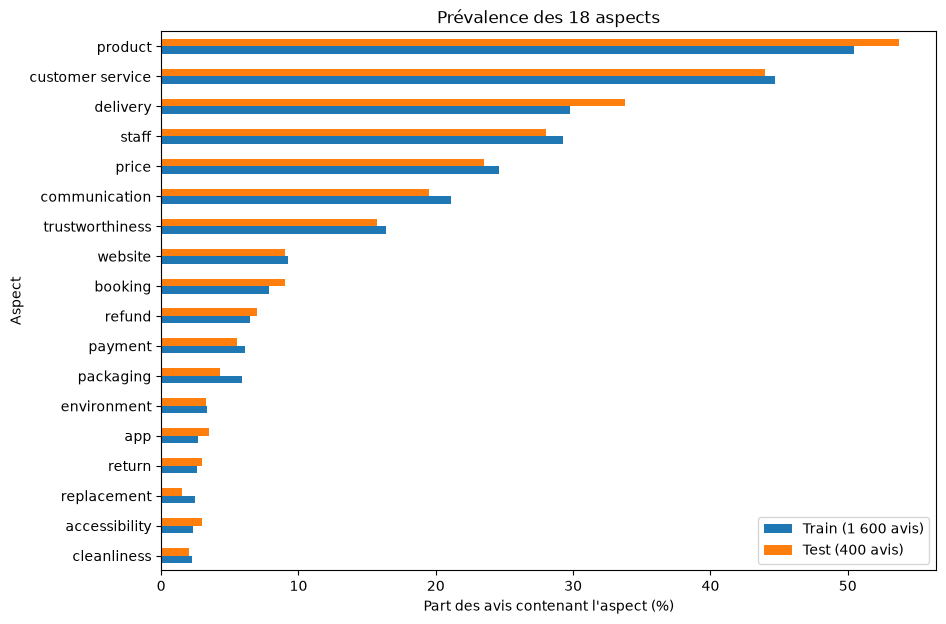

In [218]:
prevalence = pd.DataFrame({"Train (1 600 avis)": train_1600[liste_aspects].mean() * 100,
                           "Test (400 avis)": test_400[liste_aspects].mean() * 100})

prevalence = prevalence.sort_values("Train (1 600 avis)")

prevalence.plot.barh(figsize=(10, 7))

plt.title("Prévalence des 18 aspects")
plt.xlabel("Part des avis contenant l'aspect (%)")
plt.ylabel("Aspect")
plt.legend()
plt.show()

### Comparaison des prévalences entre GOLD et SILVER

Nous comparons la prévalence des 18 aspects entre GOLD et SILVER, séparément dans :

- **L’entraînement** : 400 avis GOLD et 1 200 avis SILVER.
- **Le test** : 200 avis GOLD et 200 avis SILVER.

Les comparaisons sont exprimées en **pourcentages** afin de tenir compte des tailles différentes des ensembles.

In [219]:
# Calculer la prévalence de chaque aspect dans les quatre sous-ensembles
comparaison_gold_silver = pd.DataFrame({
    "% train GOLD 400": gold_train[liste_aspects].sum() / len(gold_train) * 100,
    "% train SILVER 1200": silver_train[liste_aspects].sum() / len(silver_train) * 100,
    "% test GOLD 200": gold_test[liste_aspects].sum() / len(gold_test) * 100,
    "% test SILVER 200": silver_test[liste_aspects].sum() / len(silver_test) * 100})

# Calculer l'écart absolu GOLD/SILVER dans l'entraînement
comparaison_gold_silver["écart train GOLD_400/SILVER_1200"] = (
    comparaison_gold_silver["% train GOLD 400"]- 
    comparaison_gold_silver["% train SILVER 1200"]).abs()

# Calculer l'écart absolu GOLD/SILVER dans le test
comparaison_gold_silver["écart test GOLD_200/SILVER_200"] = (
    comparaison_gold_silver["% test GOLD 200"]
    - comparaison_gold_silver["% test SILVER 200"]).abs()

# Trier les aspects par prévalence décroissante dans l'entraînement GOLD
comparaison_gold_silver = comparaison_gold_silver.sort_values("% train GOLD 400", ascending=False)

# Afficher les résultats arrondis à une décimale
display(comparaison_gold_silver.round(1))


,% train GOLD 400,% train SILVER 1200,% test GOLD 200,% test SILVER 200,écart train GOLD_400/SILVER_1200,écart test GOLD_200/SILVER_200
product,56.2,48.5,52.5,55.0,7.8,2.5
customer service,50.7,42.7,47.5,40.5,8.1,7.0
delivery,30.0,29.7,35.5,32.0,0.3,3.5
staff,25.2,30.6,28.5,27.5,5.3,1.0
price,24.2,24.8,23.0,24.0,0.5,1.0
communication,18.5,22.0,20.5,18.5,3.5,2.0
trustworthiness,13.0,17.5,14.0,17.5,4.5,3.5
website,8.0,9.7,8.5,9.5,1.7,1.0
environment,5.8,2.5,4.5,2.0,3.2,2.5
payment,5.2,6.4,4.5,6.5,1.2,2.0


Les deux colonnes d’écart mesurent les différences absolues de prévalence entre GOLD et SILVER, séparément dans l’entraînement et dans le test. Elles sont exprimées en **points de pourcentage**.

Un écart faible indique que l’aspect est présent dans des proportions proches dans les deux ensembles concernés.

Cette comparaison décrit la répartition des aspects. Elle ne mesure pas directement la qualité des annotations SILVER : des prévalences similaires ne suffisent pas à établir que les annotations sont correctes.

Dans l’entraînement, les écarts les plus importants concernent **customer service** (8,1 points) et **product** (7,8 points), davantage représentés dans GOLD. À l’inverse, **staff** est davantage représenté dans SILVER, avec un écart de 5,3 points.

Dans le test, les écarts les plus élevés concernent **customer service** et **booking**, avec 7 points chacun. Le premier est davantage représenté dans GOLD, tandis que le second est davantage représenté dans SILVER. L’aspect **accessibility** présente également un écart de 4 points, avec une prévalence plus élevée dans GOLD.

Ces différences portent sur des ensembles d’avis distincts. Elles décrivent des écarts de répartition, mais ne permettent pas, à elles seules, de déterminer si les annotations SILVER sont correctes ou incorrectes.

Enfin, le jeu d’entraînement contient **25 % de GOLD et 75 % de SILVER**, contre **50 % de chaque origine dans le test**. La comparaison séparée de GOLD et SILVER complète donc la comparaison globale entre entraînement et test.

### Comparaison des prévalences entre l’entraînement GOLD et le test GOLD

Nous comparons la prévalence des 18 aspects entre les **400 avis GOLD d’entraînement** et les **200 avis GOLD de test**.

Les résultats, exprimés en **pourcentages**, permettent d’observer les écarts de répartition des aspects au sein des données GOLD après la séparation.

In [220]:
# Calculer la prévalence des aspects dans l'entraînement et le test GOLD
comparaison_split_gold = pd.DataFrame({
    "% GOLD train 400": gold_train[liste_aspects].sum() / len(gold_train) * 100,
    "% GOLD test 200": gold_test[liste_aspects].sum() / len(gold_test) * 100})

# Calculer l'écart absolu en points de pourcentage
comparaison_split_gold["écart"] = (comparaison_split_gold["% GOLD train 400"]
                                   - comparaison_split_gold["% GOLD test 200"]).abs()

# Trier les aspects par prévalence décroissante dans l'entraînement GOLD
comparaison_split_gold = comparaison_split_gold.sort_values("% GOLD train 400", ascending=False)

# Afficher les résultats arrondis à une décimale
display(comparaison_split_gold.round(1))

,% GOLD train 400,% GOLD test 200,écart
product,56.2,52.5,3.8
customer service,50.7,47.5,3.2
delivery,30.0,35.5,5.5
staff,25.2,28.5,3.2
price,24.2,23.0,1.2
communication,18.5,20.5,2.0
trustworthiness,13.0,14.0,1.0
website,8.0,8.5,0.5
environment,5.8,4.5,1.2
payment,5.2,4.5,0.8


La colonne « écart » mesure la différence absolue de prévalence entre l’entraînement GOLD et le test GOLD, en **points de pourcentage**.

La stratification utilisée lors de la séparation repose sur le couple **catégorie-note**. Les proportions de chaque aspect peuvent donc varier entre les deux ensembles. Ce tableau permet d’observer ces variations.

Les **18 aspects sont présents dans l’entraînement GOLD et dans le test GOLD**.

L’écart le plus important concerne **delivery**, présent dans 30 % des avis d’entraînement contre 35,5 % des avis de test, soit **5,5 points de différence**. L’aspect **product** présente ensuite un écart de **3,8 points**, avec une prévalence plus faible dans le test. Les autres écarts affichés ne dépassent pas 3,2 points.

Les écarts absolus doivent aussi être examinés pour les aspects rares. Par exemple, la prévalence d’**accessibility** passe de 2,5 % à 5 % : elle double malgré un écart de seulement 2,5 points. De même, **replacement** ne concerne que **2 avis dans le test GOLD**, ce qui limitera la portée de son évaluation.


### Comparaison des prévalences entre l’entraînement SILVER et le test SILVER

Nous comparons la prévalence des 18 aspects entre les **1 200 avis SILVER d’entraînement** et les **200 avis SILVER de test**.

Les résultats, exprimés en **pourcentages**, permettent d’observer les écarts de répartition des aspects au sein des données SILVER après la séparation.

La stratification ayant été réalisée sur le couple **catégorie–note**, la répartition des aspects n’était pas directement contrôlée lors de la séparation. Ce tableau permet d’en observer les variations.

In [221]:
# Calculer la prévalence des aspects dans l'entraînement et le test SILVER
comparaison_split_silver = pd.DataFrame({
    "% SILVER train 1200": silver_train[liste_aspects].sum() / len(silver_train) * 100,
    "% SILVER test 200": silver_test[liste_aspects].sum() / len(silver_test) * 100})

# Calculer l'écart absolu en points de pourcentage
comparaison_split_silver["écart"] = (comparaison_split_silver["% SILVER train 1200"]
                                     - comparaison_split_silver["% SILVER test 200"]).abs()

# Trier les aspects par prévalence décroissante dans l'entraînement SILVER
comparaison_split_silver = comparaison_split_silver.sort_values("% SILVER train 1200", 
                                                                ascending=False)

# Afficher les résultats arrondis à une décimale
display(comparaison_split_silver.round(1))

,% SILVER train 1200,% SILVER test 200,écart
product,48.5,55.0,6.5
customer service,42.7,40.5,2.2
staff,30.6,27.5,3.1
delivery,29.7,32.0,2.3
price,24.8,24.0,0.8
communication,22.0,18.5,3.5
trustworthiness,17.5,17.5,0.0
website,9.7,9.5,0.2
booking,8.8,12.5,3.7
refund,7.0,6.0,1.0


La colonne « écart » mesure la différence absolue de prévalence entre l’entraînement SILVER et le test SILVER, en **points de pourcentage**.

Comme pour GOLD, la stratification repose sur le couple **catégorie–note**. Ce tableau permet d’observer les variations de prévalence des aspects après la séparation.

Les **18 aspects sont présents dans l’entraînement et dans le test SILVER**.

L’écart le plus important concerne **product**, présent dans 48,5 % des avis d’entraînement contre 55 % des avis de test, soit **6,5 points de différence**. L’aspect **booking** est également davantage représenté dans le test, avec un écart de **3,7 points**.

À l’inverse, **communication** et **staff** sont moins représentés dans le test, avec des écarts respectifs de **3,5 et 3,1 points**. D’autres aspects présentent des prévalences très proches : **trustworthiness** atteint exactement 17,5 % dans les deux ensembles.

Certains aspects restent peu représentés dans les 200 avis de test SILVER : **accessibility** concerne seulement **2 avis**, et **cleanliness**, **3 avis**. Les performances sur ces aspects devront être interprétées en tenant compte de ces faibles effectifs.

### Biais potentiels et conséquences sur l’apprentissage et l’évaluation

Les comparaisons permettent d’identifier quatre points de vigilance.

**1. Un risque de mauvaise détection des aspects rares**

Dans l’entraînement, `cleanliness` concerne seulement 36 avis sur 1 600, contre 807 pour product. Pour `cleanliness`, le modèle dispose donc de 36 exemples de présence et de 1 564 exemples d’absence.

Un modèle prédisant toujours « absent » obtiendrait déjà 97,75 % de bonnes réponses sur cet aspect, sans jamais le détecter. Cet exemple montre pourquoi une proportion élevée de bonnes réponses peut être trompeuse.

Il faudra examiner le rappel et le F1 par aspect, avec leurs effectifs. Le micro-F1 et le macro-F1 apporteront deux lectures complémentaires : le premier agrège les résultats, tandis que le second donne le même poids à chaque aspect.

**2. Un risque d’instabilité des scores en validation et en test**

Dans le test GOLD, `replacement` ne concerne que 2 avis. En détecter un ou deux fait passer son rappel de 50 % à 100 %. Une forte variation de score peut donc dépendre de quelques avis.

Ce problème peut aussi se présenter dans les ensembles de validation, plus petits que l’entraînement complet. La sélection des hyperparamètres ou du seuil pourrait alors dépendre fortement des quelques exemples rares présents dans la validation.

La présence des 18 aspects dans le train et le test ne garantit pas leur bonne représentation dans chaque ensemble de validation.

**3. Un risque lié aux annotations automatiques majoritaires**

Les annotations SILVER représentent 75 % des avis d’entraînement. Si elles contiennent des erreurs récurrentes, le modèle pourrait apprendre à les reproduire. Une évaluation sur des annotations automatiques pourrait également valoriser cet accord, même lorsque certaines annotations sont incorrectes.

Les écarts GOLD/SILVER observés, notamment pour customer service et product, signalent des différences à examiner. Ils ne prouvent cependant pas des erreurs d’annotation : les ensembles contiennent des avis différents.

Les performances sur le test GOLD devront donc servir de référence principale, avec une lecture complémentaire des résultats sur SILVER.

**4. Un risque de comparaison trompeuse entre validation et test**

L’entraînement contient 25 % de GOLD et 75 % de SILVER, contre 50 % de chaque origine dans le test. Si la validation reprend la composition de l’entraînement, son score global et celui du test porteront sur des mélanges différents.

Les prévalences varient également au sein de chaque origine : delivery augmente de 5,5 points entre GOLD train et GOLD test ; product augmente de 6,5 points entre SILVER train et SILVER test.

Un écart de performance entre validation et test peut donc refléter en partie ces différences de composition. Il ne doit pas être attribué automatiquement au surapprentissage.

**Conséquences pour la suite**

- Contrôler les effectifs des aspects et la répartition GOLD/SILVER dans les ensembles de validation.
- Examiner les scores par aspect et par origine des annotations, en complément des scores globaux.
- Choisir les hyperparamètres et les seuils uniquement à partir de la validation issue de l’entraînement.
- Conserver les jeux de test pour l’évaluation finale, sans refaire le découpage pour obtenir de meilleurs résultats.

### Export des jeux d’entraînement et de test

Nous enregistrons `train_1600` et `test_400` afin de conserver le découpage retenu et de le réutiliser pour comparer les modèles sur les mêmes avis d’entraînement et de test.

In [222]:
# Exporter le jeu d'entraînement aux formats CSV et Excel
#train_1600.to_csv("../data/train_1600.csv", index=False)
#train_1600.to_excel("../data/train_1600.xlsx", index=False)

# Exporter le jeu de test aux formats CSV et Excel
#test_400.to_csv("../data/test_400.csv", index=False)
#test_400.to_excel("../data/test_400.xlsx", index=False)

## TF-IDF et régression logistique en One-vs-Rest

Nous construisons un premier modèle de détection des aspects, qui servira de référence pour comparer les modèles suivants.

Cette approche comprend deux étapes :

1. **La vectorisation TF-IDF** transforme les textes des avis en variables numériques.
2. **La régression logistique en One-vs-Rest** utilise ces variables pour détecter les aspects présents dans chaque avis.

### Vectorisation des textes avec TF-IDF

Le **TF-IDF** (*Term Frequency – Inverse Document Frequency*) transforme les textes en représentations numériques, en pondérant les termes selon leur fréquence dans un avis et dans l’ensemble des textes d’entraînement.

Paramètres utilisés :

- `lowercase=True` : conversion des textes en minuscules ;
- `ngram_range=(1, 2)` : prise en compte des mots seuls et des groupes de deux mots ;
- `min_df=2` : conservation des termes présents dans au moins deux avis d’entraînement ;
- `max_features=20000` : limitation à 20 000 variables TF-IDF au maximum.

Le vocabulaire et les poids IDF sont appris **uniquement sur le jeu d’entraînement**, avec `fit_transform()`.

Le jeu de test est ensuite transformé avec `transform()`, en réutilisant ce vocabulaire et ces poids IDF. Les textes du test n’interviennent donc pas dans l’apprentissage du TF-IDF.

### Vectorisation des textes avec TF-IDF

Afin d’utiliser les avis textuels comme entrée des modèles de Machine Learning, les textes sont transformés en représentations numériques grâce au **TF-IDF** (*Term Frequency – Inverse Document Frequency*).

Le vocabulaire et les poids IDF sont appris **uniquement sur le jeu d’entraînement**, avec `fit_transform()`. Cela évite que les textes du jeu de test influencent cet apprentissage.

Paramètres utilisés :

- `lowercase=True` : conversion des textes en minuscules ;
- `ngram_range=(1, 2)` : prise en compte des mots seuls et des groupes de deux mots ;
- `min_df=2` : conservation des termes présents dans au moins deux avis d’entraînement ;
- `max_features=20000` : limitation à 20 000 variables TF-IDF au maximum.

Le jeu de test est ensuite vectorisé avec `transform()`, en utilisant le **même vocabulaire et les mêmes poids IDF**, sans les réapprendre sur les textes de test.

In [223]:
# Séparer les textes et les labels d'aspects
X_train = train_1600["texte_complet"]
y_train = train_1600[liste_aspects]

X_test = test_400["texte_complet"]
y_test = test_400[liste_aspects]


# Initialiser la vectorisation TF-IDF
tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=20000)

# Apprendre le vocabulaire sur l'entraînement et transformer les textes
X_train_tfidf = tfidf.fit_transform(X_train)

# fit_transform() apprend le vocabulaire et transforme les textes d’entraînement. 
# transform() applique exactement cette représentation aux textes de test, 
# sans réapprendre le TF-IDF.

# Transformer le test avec le même vocabulaire (sans réapprendre le TF-IDF)
X_test_tfidf = tfidf.transform(X_test)


print("Train TF-IDF :", X_train_tfidf.shape)
print("Test TF-IDF :", X_test_tfidf.shape)

Train TF-IDF : (1600, 14705)
Test TF-IDF : (400, 14705)


### Résultat de la vectorisation

Après vectorisation :

- le jeu d’entraînement contient **1 600 avis** ;
- le jeu de test contient **400 avis** ;
- chaque avis est représenté par **14 705 variables TF-IDF**.

La limite de 20 000 variables n’a pas été atteinte : les paramètres de vectorisation et les textes d’entraînement ont conduit à conserver 14 705 termes et n-grammes.

Les colonnes des deux matrices correspondent aux mêmes termes, dans le même ordre.

### Enregistrement du TF-IDF et de la liste des aspects

Nous enregistrons deux éléments pour pouvoir réutiliser les modèles sur de nouveaux avis :

- **`tfidf`** : le vectoriseur appris, contenant notamment le vocabulaire et les poids IDF ;
- **`liste_aspects`** : les noms des 18 aspects dans l’ordre utilisé pour construire les cibles.

Les modèles d’aspects entraînés sur `X_train_tfidf` utilisent ce même vectoriseur. Il pourra donc servir à la régression logistique, au SVM et à XGBoost, à condition qu’ils soient entraînés sur cette même représentation.

Les modèles seront enregistrés séparément après leur entraînement.

In [224]:
# Créer le dossier de sauvegarde s'il n'existe pas
os.makedirs("../models", exist_ok=True)

# Enregistrer le vectoriseur appris et l'ordre des aspects
#joblib.dump(tfidf, "../models/tfidf_aspects.joblib")
#joblib.dump(liste_aspects, "../models/liste_aspects.joblib")
print("TF-IDF et liste des aspects enregistrés.")

TF-IDF et liste des aspects enregistrés.


In [225]:
df_tfidf_train = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())

df_tfidf_train.to_csv("X_train_tfidf.csv", index=False, encoding="utf-8-sig")

df_tfidf_test = pd.DataFrame(X_test_tfidf.toarray(), columns=tfidf.get_feature_names_out())

df_tfidf_test.to_csv("X_test_tfidf.csv", index=False, encoding="utf-8-sig")

In [128]:
# Recharger le vectoriseur appris
#tfidf = joblib.load("../models/tfidf_aspects.joblib")

# Recharger le vectoriseur appris de l'ordre des aspects
#liste_aspects = joblib.load("../models/liste_aspects.joblib")

## Etapes :

- Évaluer le dummy stratifié pour obtenir une référence sans exploiter les textes.
  
- Entraîner LR, SVM et XGBoost sur le train avec `OneVsRestClassifier` : un classifieur binaire pour chacun des 18 aspects.
  
- Comparer leurs performances sur le test, globalement puis par aspect.
  
- Comparer également les trois modèles en validation croisée sur le train.
  
- Retenir le modèle à optimiser en s’appuyant sur le Macro-F1 moyen obtenu en validation croisée.
  
- Optimiser ses paramètres sur le train avec `GridSearchCV`, en utilisant un découpage `KFold`.
  
- Évaluer le modèle optimisé sur le test avec le Micro-F1 et le Macro-F1.
  
- Rechercher un seuil de décision sur un jeu de validation issu du train, puis appliquer le seuil retenu au test.
  
- Évaluer séparément les modèles sur les parties GOLD et SILVER du test, sans les réentraîner.
  
- Examiner les dix termes aux coefficients positifs les plus élevés pour chaque aspect du modèle optimisée, afin d’identifier les mots et groupes de mots qui favorisent la prédiction de cet aspect.
  
- Sauvegarder les modèles et les éléments nécessaires à leur réutilisation : TF-IDF et ordre des aspects.

### Référence naïve : DummyClassifier

Avant d'évaluer les modèles de détection des aspects, nous calculons une référence avec `DummyClassifier`. Ce classifieur ignore le texte et utilise uniquement la répartition des labels dans le jeu d'entraînement.

La stratégie `stratified` prédit aléatoirement la présence ou l'absence de chaque aspect selon sa fréquence dans le train. Par ex., un aspect présent dans 30 % des avis d'entraînement aura une probabilité de 30 % d'être prédit présent pour chaque avis du test.

Cette référence permet de vérifier ce que les modèles apportent en exploitant le contenu des avis.

Nous utilisons le même jeu de test et les mêmes métriques principales :

- **Micro-F1** : évaluation globale des détections d'aspects ;
- **Macro-F1** : moyenne des F1 des 18 aspects, avec le même poids pour chacun.

En complément, l'**accuracy exacte** mesure la proportion d'avis dont les 18 labels sont tous correctement prédits, sans aspect oublié ni ajouté.

Le paramètre `random_state=42` rend les prédictions aléatoires reproductibles.

In [226]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Créer une référence aléatoire fondée sur la fréquence de chaque aspect
modele_dummy = DummyClassifier(strategy="stratified", random_state=42)

# Apprendre uniquement la répartition des labels dans le train
# Le dummy ignore les valeurs des variables TF-IDF
modele_dummy.fit(X_train_tfidf, y_train)

# Prédire les 18 aspects sur les mêmes avis de test
y_pred_dummy = modele_dummy.predict(X_test_tfidf)

# Évaluer avec les mêmes métriques que les autres modèles
print("Micro-F1 dummy :", round(f1_score(y_test, 
                                         y_pred_dummy, 
                                         average="micro", 
                                         zero_division=0), 3))

print("Macro-F1 dummy :", round(f1_score(y_test, 
                                         y_pred_dummy, 
                                         average="macro", 
                                         zero_division=0), 3))

# Proportion d'avis dont les 18 labels sont tous correctement prédits
print("Accuracy exacte dummy :", round( accuracy_score(y_test, 
                                                       y_pred_dummy), 3))

Micro-F1 dummy : 0.307
Macro-F1 dummy : 0.14
Accuracy exacte dummy : 0.007


### Résultats du modèle de référence naïf

Le DummyClassifier stratifié obtient un **Micro-F1 de 0,307** et un **Macro-F1 de 0,140**, sans exploiter le contenu des avis. Ces prédictions reposent uniquement sur la fréquence de chaque aspect dans le jeu
d'entraînement.

L'accuracy exacte indique qu'environ **0,7 % des avis** ont leurs 18 labels entièrement corrects, sans aspect oublié ni ajouté.

Cette référence dépend d'un tirage aléatoire, rendu reproductible avec `random_state=42`.

Ces résultats constituent une référence pour évaluer, dans la suite du notebook, l'apport des modèles entraînés sur les textes

In [227]:
# Pour aller loin :
# Récupérer les annotations du test sous forme de tableau NumPy
annotations = y_test.to_numpy()

# Compter les résultats sur tous les avis et tous les aspects
VP = ((annotations == 1) & (y_pred_dummy == 1)).sum()
FP = ((annotations == 0) & (y_pred_dummy == 1)).sum()
FN = ((annotations == 1) & (y_pred_dummy == 0)).sum()

print("Vrais positifs :", VP)
print("Faux positifs :", FP)
print("Faux négatifs :", FN)

# Retrouver le Micro-F1 affiché précédemment
print("Micro-F1 recalculé :", round(2 * VP / (2 * VP + FP + FN), 3))

Vrais positifs : 327
Faux positifs : 725
Faux négatifs : 750
Micro-F1 recalculé : 0.307


## Retrouver le Micro-F1 affiché précédemment
print("Micro-F1 recalculé :", round(2 * VP / (2 * VP + FP + FN), 3))


Le dummy détecte correctement 327 présences d'aspects, en ajoute 725 à tort et en manque 750. Ces effectifs sont cumulés sur les 18 aspects.

Le Micro-F1 vaut donc : 2 × 327 / (2 × 327 + 725 + 750) ≈ 0,307.

Ce score constitue la référence obtenue par des prédictions aléatoires fondées sur les fréquences du train, sans exploiter le texte des avis.

In [228]:
VN = ((annotations == 0) & (y_pred_dummy == 0)).sum()
print("Vrais négatifs :", VN)

Vrais négatifs : 5398


### Matrice de confusion du dummy - résultats cumulés sur les 18 aspects

Les résultats sont regroupés sur les **400 avis et les 18 aspects**,
soit **7 200 décisions de présence ou d'absence**.

| Annotation réelle | Prédit absent (0) | Prédit présent (1) |
|---|---:|---:|
| **Absent (0)** | **VN = 5 398** | **FP = 725** |
| **Présent (1)** | **FN = 750** | **VP = 327** |

- **VN** : vrai negatif; aspect absent, correctement prédit absent.
- **FP** : faux positif; aspect ajouté à tort.
- **FN** : faux negatif; aspect présent mais non détecté.
- **VP** : vrai positif; aspect présent et correctement détecté.

Chaque effectif compte des couples **avis–aspect**, et non des avis distincts.
Le Micro-F1 utilise les VP, FP et FN ; les VN n'interviennent pas dans son calcul.

#### Exemple F1 dummy - product

In [229]:
# Repérer la colonne correspondant à product dans les prédictions
i = liste_aspects.index("product")

# Calculer le F1 réellement obtenu par le dummy pour cet aspect
print("F1 dummy - product :", round(
    f1_score(y_test["product"], y_pred_dummy[:, i], zero_division=0), 3))

F1 dummy - product : 0.562


Le dummy obtient un **F1 de 0,562 pour `product`**, sans lire les avis.

Ce résultat est à rapprocher de la fréquence élevée de cet aspect : **50,4 % des avis du train** et **53,8 % des avis du test**.
Le dummy prédit donc sa présence avec une probabilité de 50,4 % pour chaque avis. Comme `product` est réellement présent dans plus de la moitié du test, certaines de ces prédictions sont correctes par hasard.

Cet exemple montre qu'un aspect fréquent peut obtenir un F1 non négligeable sans apprentissage du texte. Il faudra donc comparer les modèles à cette référence pour apprécier leur apport.

### Conserver les scores du dummy pour les comparaisons

In [230]:
# Conserver les scores du dummy pour les comparaisons suivantes
comparaison_dummy = pd.DataFrame(
    {"Modèle": ["Dummy stratifié"],
    "Micro-F1": [f1_score(y_test, y_pred_dummy, average="micro", zero_division=0)],
    "Macro-F1": [f1_score(y_test, y_pred_dummy, average="macro", zero_division=0)]})

In [231]:
# Enregistrer les scores pour la comparaison finale avec DistilBERT
#joblib.dump(comparaison_dummy,"../models/resultats_dummy_aspects.joblib")

['../models/resultats_dummy_aspects.joblib']

In [118]:
# Recharge comparaison_dummy
comparaison_dummy = joblib.load("../models/resultats_dummy_aspects.joblib")

### Calcul des performances du dummy pour chaque aspect

In [232]:
# Calculer les performances du dummy pour chaque aspect
rapport_dummy = classification_report(y_test,
                                      y_pred_dummy,
                                      target_names=liste_aspects,
                                      output_dict=True,
                                      zero_division=0)

resultats_dummy = pd.DataFrame(rapport_dummy).T

resultats_dummy_aspects = resultats_dummy.loc[liste_aspects,
    ["precision", "recall", "f1-score", "support"]]

### Régression logistique en One-vs-Rest

La détection des aspects est un problème de **classification multi-label** : un même avis peut mentionner plusieurs aspects.

Nous entraînons donc **un classifieur binaire par aspect**, soit **18 régressions logistiques**. Chaque classifieur reçoit les mêmes variables TF-IDF, mais apprend à prédire une colonne différente de `y_train` :

- **1** : l’aspect est présent dans les annotations ;
- **0** : l’aspect est absent des annotations.

Nous pourrions réaliser cette étape avec une boucle Python : pour chaque aspect, créer une régression logistique et l’entraîner sur la colonne correspondante.

`OneVsRestClassifier` automatise ces opérations et regroupe les 18 classifieurs dans un seul objet, `modele_lr_aspects`. Un appel à `fit()` entraîne l’ensemble des classifieurs, puis `predict()` rassemble leurs prédictions.

Plusieurs classifieurs peuvent prédire 1 pour un même avis. Le modèle peut ainsi détecter simultanément `delivery` et `customer service`.

La régression logistique utilise les paramètres suivants :

- `max_iter=1000` : autorise jusqu’à 1 000 itérations pour l’apprentissage ;
- `class_weight="balanced"` : ajuste le poids des exemples positifs et négatifs selon leurs effectifs, séparément pour chaque aspect. Cela permet de tenir compte du déséquilibre entre présence et absence d’un aspect.

In [233]:
# Créer le modèle de régression logistique multi-label
# Un classifieur binaire est entraîné pour chaque aspect
modele_lr_aspects = OneVsRestClassifier(LogisticRegression(max_iter=1000,class_weight="balanced"))

# Entraîner les 18 classifieurs sur les données TF-IDF
modele_lr_aspects.fit(X_train_tfidf, y_train)

# Enregistrer le modèle entraîné
joblib.dump(modele_lr_aspects, "../models/modele_lr_aspects.joblib")

# Prédire la présence ou l'absence des 18 aspects pour chaque avis de test
y_pred_lr = modele_lr_aspects.predict(X_test_tfidf)

# y_pred_lr contient une matrice de dimensions 400 × 18 : une ligne par avis et une colonne 
# par aspect. Un même avis peut donc avoir plusieurs valeurs 1.

In [129]:
# Recharge modele_lr_aspects modele entrainé Lr_aspects initial
modele_lr_aspects = joblib.load("../models/modele_lr_aspects.joblib")

### Évaluation du modèle Régression logistique

Nous évaluons les prédictions sur les **400 avis du jeu de test**, avec deux métriques complémentaires :

* **Micro-F1** évalue globalement toutes les prédictions et est davantage influencé par les aspects fréquents.
* **Macro-F1** calcule un F1 pour chaque aspect, puis leur moyenne. Il permet donc de voir si les aspects rares sont également bien détectés. Chaque aspect a ainsi le même poids, qu’il soit fréquent ou rare.

Ces scores globaux seront complétés par une analyse par aspect et par des évaluations séparées sur GOLD et SILVER.

In [234]:
# Évaluer les performances globales du modèle
print("Micro-F1 :",round(f1_score(y_test, y_pred_lr, average="micro"), 3))

print("Macro-F1 :",round(f1_score(y_test, y_pred_lr, average="macro"), 3))

Micro-F1 : 0.667
Macro-F1 : 0.481


### Résultats de la première baseline

La régression logistique en One-vs-Rest obtient :

- **Micro-F1 : 0,667**
- **Macro-F1 : 0,481**

L’écart entre ces scores invite à examiner les performances par aspect, notamment celles des aspects rares. Le rapport détaillé permettra d’identifier les aspects les mieux détectés et ceux qui posent davantage de difficultés.

Ces résultats constituent notre première référence sur le jeu de test mixte GOLD et SILVER.

### Évaluation détaillée de la régression logistique par aspect

Les scores Micro-F1 et Macro-F1 résument les performances du modèle, mais ne permettent pas d’identifier les aspects les mieux détectés et ceux qui posent davantage de difficultés.

Nous calculons donc, pour chacun des 18 aspects :

- **Précision (`precision`)** : proportion de détections correctes parmi toutes les détections de cet aspect par le modèle.
- **Rappel (`recall`)** : parmi les avis annotés comme contenant l’aspect, proportion correctement détectée par le modèle ;
- **F1-score (`f1-score`)** : moyenne harmonique de la précision et du rappel, qui permet de les résumer en un seul score ;
- **Support (`support`)** : nombre d’avis du jeu de test annotés comme contenant l’aspect.

Cette analyse permet de comparer les performances selon les aspects et de les mettre en relation avec leur fréquence.

**Point de vigilance :** les scores des aspects peu présents dans le test doivent être interprétés avec prudence. Lorsque le support est faible, quelques erreurs peuvent faire fortement varier le rappel et le F1-score.

In [235]:
# Calculer les métriques et les récupérer sous forme de dictionnaire
rapport_lr = classification_report( y_test,y_pred_lr, target_names=liste_aspects, output_dict=True,
                                    zero_division=0)

# Transformer le dictionnaire en tableau
# .T place les aspects en lignes et les métriques en colonnes
resultats_lr = pd.DataFrame(rapport_lr).T

# Conserver uniquement les 18 aspects et les quatre indicateurs
resultats_lr_aspects = resultats_lr.loc[liste_aspects, 
    ["precision", "recall", "f1-score", "support"]]

# Afficher le nombre d'avis sans décimales
resultats_lr_aspects["support"] = resultats_lr_aspects["support"].astype(int)

# Classer les aspects par F1-score décroissant
resultats_lr_aspects = resultats_lr_aspects.sort_values("f1-score", ascending=False)

# Arrondir les scores uniquement pour l'affichage
display(resultats_lr_aspects.round(3))

,precision,recall,f1-score,support
product,0.767,0.767,0.767,215
delivery,0.868,0.681,0.763,135
customer service,0.740,0.761,0.751,176
staff,0.694,0.750,0.721,112
packaging,0.632,0.706,0.667,17
refund,0.708,0.607,0.654,28
price,0.636,0.670,0.653,94
communication,0.514,0.718,0.599,78
website,0.762,0.444,0.561,36
app,0.833,0.357,0.500,14


### Analyse des performances par aspect

Les performances de la Régression Logistique varient fortement selon les aspects.

Les aspects les plus fréquents sont globalement les mieux détectés :

- `product` : F1 = **0,767**
- `delivery` : F1 = **0,763**
- `customer service` : F1 = **0,751**
- `staff` : F1 = **0,721**

Le modèle obtient également des résultats intéressants sur certains aspects moins représentés, comme `packaging` (F1 = **0,667**) et `refund` (F1 = **0,654**).

En revanche, les performances diminuent fortement pour plusieurs aspects rares. `payment`, `cleanliness` et `environment` présentent des F1 inférieurs à 0,20.

Les aspects `accessibility` et `replacement` ne sont pas détectés par cette première baseline (F1 = **0**).

Ces résultats expliquent l'écart observé entre le **Micro-F1 de 0,667** et le **Macro-F1 de 0,481** : les classes fréquentes sont relativement bien reconnues, tandis que plusieurs classes rares restent difficiles à identifier.

Points de vigilance :

* Le **support** correspond aux effectifs du test. Les scores reposant sur peu d’exemples peuvent varier fortement avec quelques erreurs. Certains aspects sont présents dans très peu d’avis du jeu de test. Leur évaluation repose donc sur peu de cas : une seule détection manquée ou réussie peut faire fortement varier leurs scores.
* Ces résultats ne suffisent pas à attribuer les difficultés uniquement au manque d’exemples d’entraînement.
* Cette analyse concerne le test mixte GOLD et SILVER. Une évaluation séparée permettra de comparer les performances selon la source des annotations.
* Le faible nombre d'exemples dans le jeu de test pour certains aspects doit également être pris en compte dans l'interprétation des scores.

#### a jouter
La régression logistique obtient les meilleurs scores parmi les trois configurations initiales évaluées sur le test mixte GOLD/SILVER.

Ces résultats en font un candidat à approfondir, mais ne démontrent pas une supériorité générale sur SVM et XGBoost. L’écart réduit avec XGBoost, les limites des données et l’absence d’optimisation des modèles doivent être pris en compte.

pour cette version du projet le choix du modèle à optimiser **sera fondé sur une comparaison en validation croisée sur le jeu d’entraînement.**


**Optimiser uniquement la meilleure baseline reste un choix pratique pour limiter les calculs ; cela ne garantit pas de trouver le meilleur modèle après optimisation.**

# SVM

## Deuxième baseline : SVM linéaire en One-vs-Rest

Nous entraînons un **SVM linéaire**, avec `LinearSVC`, pour détecter les aspects présents dans les avis.

Le problème restant multi-label, la stratégie **One-vs-Rest** est conservée : un classifieur SVM binaire indépendant est entraîné pour chacun des **18 aspects**. Plusieurs aspects peuvent ainsi être détectés dans un même avis.

Nous utilisons les mêmes éléments que pour la régression logistique :

- les mêmes avis d’entraînement et de test ;
- les mêmes labels, dans le même ordre ;
- les mêmes matrices `X_train_tfidf` et `X_test_tfidf`.

**Le vectoriseur TF-IDF déjà appris est donc réutilisé : il n’est pas réentraîné pour le SVM.**

Cette étape évalue une configuration initiale du SVM, sans recherche d’hyperparamètres. Ses résultats seront ensuite regroupés avec ceux de la régression logistique et de XGBoost dans une comparaison des trois baselines.

In [236]:
# Créer le SVM multi-label : un classifieur binaire par aspect
modele_svm = OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=5000))

# Entraîner les 18 classifieurs sur les mêmes données TF-IDF que la LR
modele_svm.fit(X_train_tfidf, y_train)

# Enregistrer le modèle entraîné
joblib.dump(modele_svm, "../models/modele_svm_aspects.joblib")

# Prédire les aspects des avis du jeu de test
y_pred_svm = modele_svm.predict(X_test_tfidf)

# Calculer les scores globaux
print("Micro-F1 :", round(f1_score(y_test, y_pred_svm, average="micro"), 3))
print("Macro-F1 :", round(f1_score(y_test, y_pred_svm, average="macro"), 3))

Micro-F1 : 0.648
Macro-F1 : 0.443


In [131]:
# Recharger le modèle entraîné modele_svm_aspects
modele_svm_aspects = joblib.load("../models/modele_svm_aspects.joblib")

### Premiers résultats du SVM

Le SVM linéaire en One-vs-Rest obtient, sur les 400 avis du jeu de test mixte GOLD/SILVER :

- **Micro-F1 : 0,648** ;
- **Macro-F1 : 0,443**.

L’écart entre ces deux scores invite à examiner les performances par aspect, notamment pour les aspects peu représentés. Ces scores globaux ne permettent toutefois pas, à eux seuls, d’identifier les aspects qui posent problème.

Une évaluation détaillée par aspect complète donc ces premiers résultats. La comparaison avec la régression logistique et XGBoost sera présentée après l’évaluation des trois baselines.

## Troisième baseline : XGBoost en One-vs-Rest

Après la régression logistique et le SVM, nous entraînons un modèle **XGBoost** sur les mêmes matrices `X_train_tfidf` et `X_test_tfidf`. Le TF-IDF déjà appris est réutilisé.

XGBoost repose sur le **Gradient Boosting** : des arbres de décision sont construits successivement, chaque nouvel arbre cherchant à corriger une partie des erreurs de l’ensemble précédent.

Trois paramètres importants contrôlent cet apprentissage :

- `n_estimators` : nombre d’arbres construits pour chaque classifieur binaire ;
- `learning_rate` : contribution de chaque nouvel arbre à la prédiction ;
- `max_depth` : profondeur maximale des arbres.

Un `learning_rate` plus faible réduit la contribution de chaque arbre. Une profondeur élevée permet de construire des arbres plus complexes, mais peut augmenter le risque de surapprentissage.

Dans notre problème multi-label, `OneVsRestClassifier` entraîne **un classifieur XGBoost binaire pour chacun des 18 aspects**. Plusieurs aspects peuvent ainsi être prédits pour un même avis.

Cette baseline utilise une **configuration initiale, sans recherche d’hyperparamètres**. Ses résultats compléteront la comparaison avec la régression logistique et le SVM.

Le choix du modèle à optimiser s’appuiera ensuite sur une comparaison en validation, réalisée à partir du jeu d’entraînement.

#### A executer qu'une fois, apres il faut juste recherchreger le fichier

In [237]:
# Créer le modèle XGBoost multi-label
# Un classifieur binaire est entraîné pour chaque aspect
modele_xgb = OneVsRestClassifier(XGBClassifier(n_estimators=100, learning_rate=0.3, max_depth=6,
                                               objective="binary:logistic", eval_metric="logloss",
                                               random_state=42, n_jobs=-1))

# Entraîner les 18 classifieurs sur les mêmes données TF-IDF
modele_xgb.fit(X_train_tfidf, y_train)

# Enregistrer le modèle initial entraîné
joblib.dump(modele_xgb, "../models/modele_xgb_aspects.joblib")

# Prédire les aspects des avis du jeu de test
y_pred_xgb = modele_xgb.predict(X_test_tfidf)

# Calculer les scores globaux
print("Micro-F1 XGBoost :", round(f1_score(y_test, y_pred_xgb, average="micro"), 3))
print("Macro-F1 XGBoost :", round(f1_score(y_test, y_pred_xgb, average="macro"), 3))

Micro-F1 XGBoost : 0.648
Macro-F1 XGBoost : 0.477


In [133]:
# Recharger le modèle initial entraîné modele_xgb_aspects
modele_xgb_aspects = joblib.load("../models/modele_xgb_aspects.joblib")

### Premies résultats de XGBoost

Le modèle XGBoost en One-vs-Rest obtient, sur les 400 avis du jeu de test mixte GOLD/SILVER :

- **Micro-F1 : 0,648** ;
- **Macro-F1 : 0,477**.

Ces résultats correspondent à la configuration initiale du modèle, sans recherche d’hyperparamètres.

**Point à prendre en compte dans la comparaison :** la régression logistique et le SVM utilisent `class_weight="balanced"` pour pondérer les exemples positifs et négatifs de chaque aspect. La configuration initiale de XGBoost ne prévoit pas de pondération explicite des classes.

La prise en compte du déséquilibre diffère donc entre les configurations. Les écarts de performance observés ne peuvent pas être attribués uniquement au choix de l’algorithme.

La section suivante regroupe la comparaison des trois baselines, à partir des scores globaux et des performances par aspect.

## Comparaison des trois baselines

Nous comparons les configurations initiales de la régression logistique, du SVM et de XGBoost.

Les trois modèles utilisent les mêmes données d’entraînement, les mêmes représentations TF-IDF et le même jeu de test mixte GOLD/SILVER. Le tableau rassemble leurs scores Micro-F1 et Macro-F1.

In [238]:
# Regrouper les performances des trois modèles initiaux
comparaison_modeles = pd.DataFrame({"Modèle": ["Régression logistique initiale",
                                               "SVM initial",
                                               "XGBoost initial"],
                                    "Micro-F1": [f1_score(y_test, y_pred_lr, average="micro"),
                                                 f1_score(y_test, y_pred_svm, average="micro"),
                                                 f1_score(y_test, y_pred_xgb, average="micro")],
                                    "Macro-F1": [f1_score(y_test, y_pred_lr, average="macro"),
                                                 f1_score(y_test, y_pred_svm, average="macro"),
                                                 f1_score(y_test, y_pred_xgb, average="macro")]})

# dummy
comparaison_modeles = pd.concat([comparaison_dummy, comparaison_modeles],
                                ignore_index=True)

# Afficher le tableau complet
display(comparaison_modeles.round(3))

,Modèle,Micro-F1,Macro-F1
0,Dummy stratifié,0.307,0.140
1,Régression logistique initiale,0.667,0.481
2,SVM initial,0.648,0.443
3,XGBoost initial,0.648,0.477


### Comparaison des modèles initiaux

Les trois modèles utilisant les textes dépassent le dummy, qui obtient un **Micro-F1 de 0,307** et un **Macro-F1 de 0,140**. Ils apportent donc une amélioration par rapport aux prédictions aléatoires fondées uniquement sur les fréquences des aspects.

La **régression logistique initiale** obtient les **meilleurs** scores observés dans cette comparaison : **Micro F1 = 0,667** et **Macro-F1 = 0,481**. Par rapport au dummy, les gains sont respectivement de **0,360** et **0,341**, sur les valeurs arrondies.

XGBoost présente un Macro-F1 proche de celui de la régression logistique : **0,477**, soit un écart de seulement **0,004 sur les valeurs arrondies**.

Le SVM et XGBoost obtiennent le même Micro-F1 arrondi à trois décimales (**0,648**). XGBoost obtient toutefois un Macro-F1 supérieur à celui du SVM (**0,477 contre 0,443**).

Ces résultats décrivent les performances des configurations initiales sur ce jeu de test. Ils ne démontrent pas une supériorité générale d'un algorithme, compte tenu des réglages utilisés et des limites des données.

La comparaison par aspect permettra maintenant de préciser les différences entre les modèles. Le choix du modèle à optimiser reposera ensuite sur une comparaison en validation croisée sur le jeu d'entraînement.

### Comparaison des performances par aspect

Nous comparons les F1-scores des trois modèles initiaux pour chacun des 18 aspects, afin d’identifier leurs points forts et leurs difficultés.

La colonne **Support** indique le nombre d’avis du test annotés avec chaque aspect. Ce nombre est commun aux trois modèles plus le dummy, puisqu’ils sont évalués sur les mêmes avis.

In [239]:
# Calculer le rapport détaillé du SVM
rapport_svm = classification_report(y_test, y_pred_svm, target_names=liste_aspects,
                                    output_dict=True, zero_division=0)

resultats_svm = pd.DataFrame(rapport_svm).T

resultats_svm_aspects = resultats_svm.loc[
    liste_aspects, ["precision", "recall", "f1-score", "support"]]

# Calculer le rapport détaillé de XGBoost
rapport_xgb = classification_report(y_test, y_pred_xgb, target_names=liste_aspects, 
                                    output_dict=True, zero_division=0)

resultats_xgb = pd.DataFrame(rapport_xgb).T

resultats_xgb_aspects = resultats_xgb.loc[
    liste_aspects, ["precision", "recall", "f1-score", "support"]]

# Réunir les F1-scores des trois modèles et dummy
# Pandas aligne les résultats grâce aux noms des aspects dans l'index
evaluation_aspects = pd.DataFrame({"F1 dummy": resultats_dummy_aspects["f1-score"],
                                   "F1 LR": resultats_lr_aspects["f1-score"],
                                   "F1 SVM": resultats_svm_aspects["f1-score"],
                                   "F1 XGBoost": resultats_xgb_aspects["f1-score"],
                                   "Support": resultats_lr_aspects["support"].astype(int)})

# Conserver le même ordre de lecture que dans le tableau de la LR
evaluation_aspects = evaluation_aspects.sort_values("F1 LR", ascending=False)

evaluation_aspects.index.name = "Aspect"

# Arrondir uniquement pour l'affichage
display(evaluation_aspects.round(3))

,F1 dummy,F1 LR,F1 SVM,F1 XGBoost,Support
Aspect,,,,,
product,0.562,0.767,0.744,0.707,215
delivery,0.336,0.763,0.726,0.758,135
customer service,0.444,0.751,0.739,0.745,176
staff,0.311,0.721,0.688,0.657,112
packaging,0.000,0.667,0.480,0.710,17
refund,0.039,0.654,0.558,0.692,28
price,0.235,0.653,0.630,0.724,94
communication,0.154,0.599,0.566,0.492,78
website,0.074,0.561,0.571,0.526,36


### Analyse de la comparaison par aspect

La référence naïve permet de mieux interpréter les scores des modèles.
L'amélioration par rapport au dummy varie fortement selon les aspects.

Quelques exemples, sur les valeurs affichées :

- **`product`** : le dummy atteint déjà un F1 de **0,562**, à rapprocher
  de la fréquence élevée de cet aspect. La régression logistique atteint
  **0,767**, soit un gain de **0,205**.
- **`delivery`** : la régression logistique passe à **0,763**, contre
  **0,336** pour le dummy, soit un gain de **0,427**.
- **`payment`** : la régression logistique atteint **0,194**, contre
  **0,150** pour le dummy. Le gain reste limité à **0,044**.
  XGBoost fait mieux avec **0,286**, mais le score reste faible.

Sur ce tableau, aucun des trois modèles n'obtient un F1 inférieur à celui du dummy. Cependant, plusieurs égalités à zéro montrent que certains aspects restent sans détection correcte.

Parmi les trois modèles utilisant les textes :

- **La régression logistique obtient le meilleur F1 sur 7 aspects** :
  `product`, `delivery`, `customer service`, `staff`, `communication`,
  `trustworthiness` et `return`.
- **XGBoost obtient le meilleur F1 sur 7 aspects** :
  `packaging`, `refund`, `price`, `app`, `payment`, `cleanliness`
  et `replacement`.
- **Le SVM obtient le meilleur F1 sur 2 aspects** :
  `website` (**0,571**) et `environment` (**0,250**).

Les trois modèles obtiennent le même F1 affiché pour `booking`
(**0,500**), supérieur à celui du dummy (**0,086**).

Pour `accessibility`, les quatre modèles obtiennent un **F1 nul** : aucun ne détecte correctement cet aspect parmi les **12 avis concernés**.
Pour `replacement`, seul XGBoost obtient un F1 non nul (**0,200**), sur seulement **6 avis concernés**.

**Points de vigilance :**

- Le nombre d'aspects sur lesquels un modèle arrive en tête ne suffit
  pas à le sélectionner : l'ampleur des écarts compte également.
- Les scores reposant sur peu d'exemples, notamment `replacement`
  et `cleanliness`, peuvent varier fortement avec quelques erreurs.
- Les résultats du dummy dépendent du tirage aléatoire, fixé ici
  par `random_state=42`.
- Les modèles utilisent des configurations initiales et une prise en
  compte différente du déséquilibre des classes. Ce tableau ne permet
  pas d'isoler les causes des écarts observés.

Cette analyse complète les scores globaux. La comparaison des trois modèles classiques en validation croisée sur le train permettra ensuite de sélectionner le modèle à optimiser.

## Comparaison des baselines par validation croisée

Nous comparons les trois modèles sur les **1 600 avis du jeu d’entraînement**, avec une validation croisée à **5 plis**.

À chaque tour :

- **1 280 avis** servent à l’entraînement ;
- **320 avis** servent à la validation.

Les mêmes découpages sont utilisés pour les trois modèles.

Un `Pipeline` associe le TF-IDF au classifieur. Dans chaque pli, le vocabulaire et les poids IDF sont appris uniquement sur les 1 280 avis d’entraînement, puis appliqués aux 320 avis de validation.

Nous comparons les **Micro-F1 et Macro-F1 moyens**, ainsi que leur **écart-type**, qui décrit la dispersion des scores entre les cinq plis.

Le **Macro-F1 moyen** est notre critère principal de sélection, afin de donner le même poids aux 18 aspects. Le Micro-F1 est également examiné.

Les 400 avis du test final ne participent pas à ces calculs. Cette validation conserve toutefois les limites de nos annotations GOLD/SILVER.

#### A executer qu'une fois, apres il faut juste recharger le fichier

In [240]:
# Définir les mêmes cinq découpages pour les trois modèles
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Réutiliser les configurations des modèles initiaux
modeles = {"Régression logistique": modele_lr_aspects, "SVM": modele_svm, "XGBoost": modele_xgb}

scores_cv = {}
resultats_cv = []

for nom_modele, modele in modeles.items():
    print(f"Validation croisée : {nom_modele}")

    # Copier la configuration sans conserver le modèle déjà entraîné
    clf = clone(modele)

    # Fixer la graine aléatoire sur les copies des classifieurs
    clf.set_params(estimator__random_state=42)

    # Copier les paramètres du TF-IDF sans reprendre son vocabulaire appris
    pipeline = Pipeline([("tfidf", clone(tfidf)), ("clf", clf)])

    # Utiliser les textes : le Pipeline réalise la vectorisation dans chaque pli
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring={ "micro": "f1_micro",
                                                                         "macro": "f1_macro"},
                            n_jobs=1, error_score="raise")

    # Conserver les scores de chaque pli
    scores_cv[nom_modele] = scores

    # Résumer les cinq scores obtenus pour chaque métrique
    resultats_cv.append({"Modèle": nom_modele, "Micro-F1 moyen": scores["test_micro"].mean(),
                         "Écart-type Micro-F1": scores["test_micro"].std(),
                         "Macro-F1 moyen": scores["test_macro"].mean(),
                         "Écart-type Macro-F1": scores["test_macro"].std()})

# Classer les configurations selon le Macro-F1 moyen
resultats_cv = pd.DataFrame(resultats_cv)

resultats_cv = resultats_cv.sort_values("Macro-F1 moyen", ascending=False)

# Enregistrer le tableau et les scores par pli
joblib.dump({"resultats_cv": resultats_cv, "scores_cv": scores_cv},
            "../models/comparaison_baselines_cv.joblib")

display(resultats_cv.round(3))

Validation croisée : Régression logistique
Validation croisée : SVM
Validation croisée : XGBoost


,Modèle,Micro-F1 moyen,Écart-type Micro-F1,Macro-F1 moyen,Écart-type Macro-F1
0,Régression logistique,0.637,0.012,0.439,0.025
2,XGBoost,0.612,0.005,0.435,0.018
1,SVM,0.622,0.014,0.397,0.014


In [35]:
sauvegarde_cv = joblib.load("../models/comparaison_baselines_cv.joblib")

resultats_cv = sauvegarde_cv["resultats_cv"]
scores_cv = sauvegarde_cv["scores_cv"]

display(resultats_cv.round(3))

,Modèle,Micro-F1 moyen,Écart-type Micro-F1,Macro-F1 moyen,Écart-type Macro-F1
0,Régression logistique,0.637,0.012,0.439,0.025
2,XGBoost,0.612,0.005,0.435,0.018
1,SVM,0.622,0.014,0.397,0.014


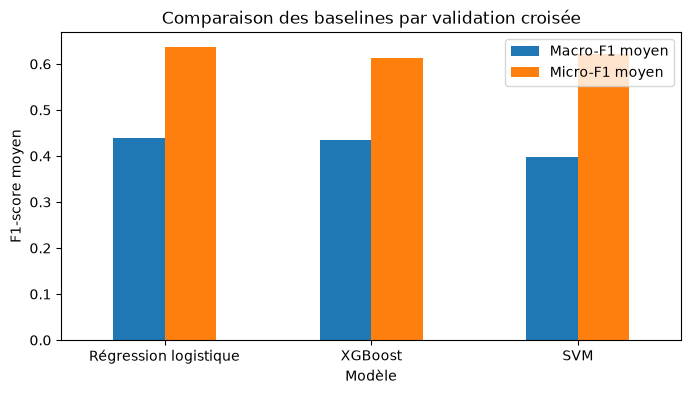

In [241]:
resultats_cv.plot(x="Modèle", y=["Macro-F1 moyen", "Micro-F1 moyen"],
                  kind="bar", figsize=(8, 4))

plt.title("Comparaison des baselines par validation croisée")
plt.ylabel("F1-score moyen")
plt.xticks(rotation=0)
plt.show()

### Analyse des résultats de la validation croisée

Sur les cinq plis, la **régression logistique** obtient les meilleurs scores moyens :

- **Micro-F1 moyen : 0,637** ;
- **Macro-F1 moyen : 0,439**.

XGBoost obtient un **Macro-F1 moyen de 0,435**, très proche de celui de la régression logistique : l’écart est de **0,004 sur les valeurs affichées**. Son Micro-F1 moyen est cependant inférieur : **0,612 contre 0,637**.

Le SVM obtient un Micro-F1 moyen de **0,622** et un Macro-F1 moyen de **0,397**. Il se situe donc entre les deux autres modèles en Micro-F1, mais présente le Macro-F1 moyen le plus faible.

Les écarts-types indiquent également des différences de dispersion entre les plis :

- régression logistique : **0,025** pour le Macro-F1 ;
- XGBoost : **0,018** ;
- SVM : **0,014**.

La régression logistique présente ainsi le meilleur Macro-F1 moyen, mais aussi la plus forte dispersion sur cette métrique. Son faible avantage moyen sur XGBoost doit donc être interprété avec prudence.

**Nous retenons la régression logistique pour la phase d’optimisation**, car elle arrive en tête sur notre critère principal, le Macro-F1 moyen, tout en obtenant le meilleur Micro-F1 moyen.

Ce choix concerne les configurations initiales évaluées. Il ne démontre pas que la régression logistique resterait meilleure après optimisation de tous les modèles.

Enfin, les scores de validation croisée ne doivent pas être directement interprétés comme une baisse par rapport aux scores précédents du test : chaque modèle apprend ici sur **1 280 avis**, et les groupes de validation diffèrent du test final, notamment par leur composition GOLD/SILVER.

La prochaine étape consiste à rechercher les paramètres `C` et `solver` de la régression logistique par validation croisée sur le train.

## Optimisation de la régression logistique

La validation croisée a montré que la régression logistique était la meilleure candidate parmi les trois modèles initiaux.

Nous recherchons maintenant une meilleure combinaison des paramètres `C` et `solver`.

Le paramètre `C` contrôle la régularisation :

- une faible valeur de `C` impose une régularisation plus forte ;
- une valeur élevée de `C` permet davantage au modèle de s’adapter aux données d’entraînement.

Le paramètre `solver` correspond à l’algorithme utilisé pour résoudre le problème d’optimisation.

La recherche utilise le Macro-F1 comme critère principal, car cette métrique donne le même poids aux 18 aspects, y compris les aspects rares.

Le jeu de test de 400 avis n’est pas utilisé pendant cette recherche.

#### A executer qu'une fois, apres il faut juste recharger le fichier

In [242]:

modele_lr_aspects_cv = OneVsRestClassifier(LogisticRegression(max_iter=3000, class_weight="balanced"))

parametres = {"estimator__C": [0.01, 0.1, 1, 10],"estimator__solver": ["liblinear", "lbfgs"]}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_lr_aspects = GridSearchCV(modele_lr_aspects_cv, param_grid=parametres, scoring="f1_macro", cv=cv, n_jobs=-1)

grid_lr_aspects.fit(X_train_tfidf, y_train)

print("Meilleurs paramètres :", grid_lr_aspects.best_params_)
print("Meilleur Macro-F1 CV :", round(grid_lr_aspects.best_score_, 3))

# Enregistrer la recherche terminée et le meilleur modèle entraîné
joblib.dump(grid_lr_aspects, "../models/grid_lr_aspects.joblib")
print("Recherche d'hyperparamètres LR enregistrée.")

Meilleurs paramètres : {'estimator__C': 0.01, 'estimator__solver': 'liblinear'}
Meilleur Macro-F1 CV : 0.474
Recherche d'hyperparamètres LR enregistrée.


In [189]:
# Recharger la recherche déjà effectuée
grid_lr_aspects = joblib.load("../models/grid_lr_aspects.joblib")

# Consulter les résultats sans relancer l'optimisation
print("Meilleurs paramètres :", grid_lr_aspects.best_params_)
print("Meilleur Macro-F1 CV :", round(grid_lr_aspects.best_score_, 3))

# Récupérer le meilleur modèle déjà entraîné
modele_lr_opt_aspects = grid_lr_aspects.best_estimator_

Meilleurs paramètres : {'estimator__C': 0.01, 'estimator__solver': 'liblinear'}
Meilleur Macro-F1 CV : 0.474


In [243]:
y_pred_lr_opt_aspects = modele_lr_opt_aspects.predict(X_test_tfidf)

print("Micro-F1 LR optimisée :", round(f1_score(y_test, y_pred_lr_opt_aspects, average="micro"), 3))

print("Macro-F1 LR optimisée :", round(f1_score(y_test, y_pred_lr_opt_aspects, average="macro"), 3))

Micro-F1 LR optimisée : 0.615
Macro-F1 LR optimisée : 0.524


Le TF-IDF a été appris avant la validation croisée sur l'ensemble des avis d'entraînement. Le jeu de test reste séparé et n'intervient pas dans l'optimisation, mais les scores de validation peuvent être légèrement optimistes, car le vocabulaire TF-IDF a été appris avant la création des plis.

### Résultats de l'optimisation de la régression logistique

La recherche par validation croisée sélectionne les paramètres suivants :

- `C = 0,01` ;
- `solver = "liblinear"`.

Le meilleur Macro-F1 moyen obtenu pendant la validation croisée est de **0,474**.

Sur le jeu de test, la régression logistique optimisée obtient :

- Micro-F1 : **0,615** ;
- Macro-F1 : **0,524**.

Par rapport à la régression logistique initiale, le Macro-F1 augmente de **0,481** à **0,524**. Le modèle obtient donc une meilleure moyenne sur les 18 aspects.

En revanche, le Micro-F1 diminue de **0,667** à **0,615**. L'amélioration du Macro-F1 se fait donc au prix d'une baisse des performances globales, davantage influencées par les aspects fréquents.

Le choix entre les deux modèles dépend donc de la métrique privilégiée. Dans la suite, les performances seront analysées aspect par aspect avant de retenir définitivement une configuration.

In [244]:
rapport_lr_opt = classification_report(y_test, y_pred_lr_opt_aspects,
                                       target_names=liste_aspects, 
                                       output_dict=True,
                                       zero_division=0)

resultats_lr_opt = pd.DataFrame(rapport_lr_opt).T

resultats_lr_opt_aspects = resultats_lr_opt.loc[liste_aspects,
    ["precision", "recall", "f1-score", "support"]]

resultats_lr_opt_aspects["support"] = (resultats_lr_opt_aspects["support"].astype(int))

resultats_lr_opt_aspects = resultats_lr_opt_aspects.sort_values("f1-score",ascending=False)

display(resultats_lr_opt_aspects.round(3))

,precision,recall,f1-score,support
product,0.726,0.800,0.761,215
delivery,0.797,0.726,0.760,135
customer service,0.674,0.847,0.751,176
staff,0.588,0.804,0.679,112
return,0.778,0.583,0.667,12
price,0.441,0.840,0.579,94
app,0.533,0.571,0.552,14
website,0.526,0.556,0.541,36
cleanliness,0.455,0.625,0.526,8
packaging,0.378,0.824,0.519,17


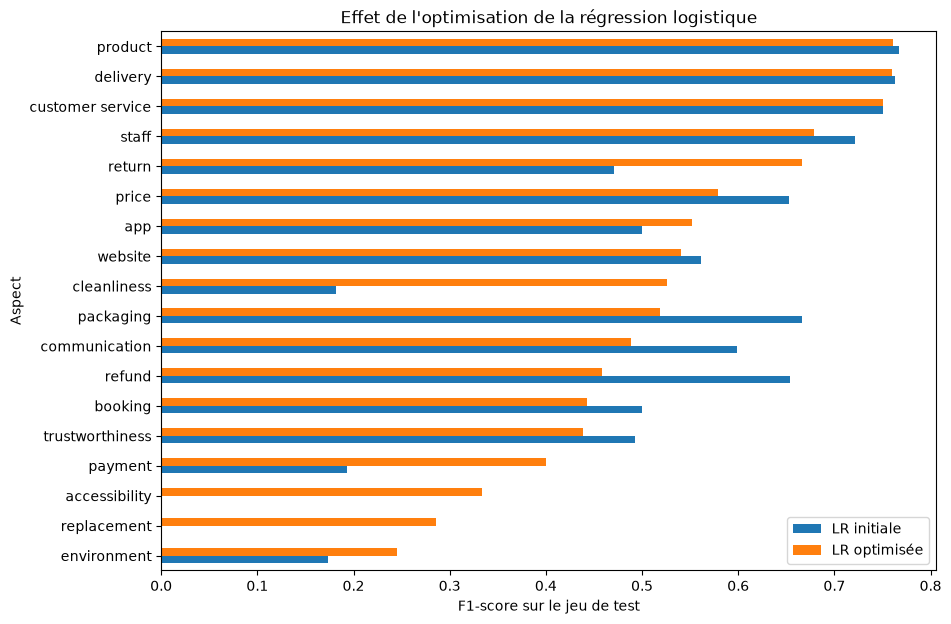

In [245]:
comparaison_lr_opt = pd.DataFrame({"LR initiale": resultats_lr_aspects["f1-score"],
                                   "LR optimisée": resultats_lr_opt_aspects["f1-score"]})

comparaison_lr_opt = comparaison_lr_opt.sort_values("LR optimisée", ascending=True)

comparaison_lr_opt.plot(kind="barh", figsize=(10, 7))

plt.title("Effet de l'optimisation de la régression logistique")
plt.xlabel("F1-score sur le jeu de test")
plt.ylabel("Aspect")
plt.legend()
plt.show()

### Analyse de l'effet de l'optimisation par aspect

L'optimisation modifie le compromis entre la précision et le rappel.

Les gains les plus importants concernent plusieurs aspects peu représentés :

- `cleanliness` : F1 de **0,182** à **0,526** ;
- `accessibility` : F1 de **0** à **0,333** ;
- `replacement` : F1 de **0** à **0,286** ;
- `payment` : F1 de **0,194** à **0,400** ;
- `return` : F1 de **0,471** à **0,667**.

Les aspects fréquents restent relativement stables :

- `product` : F1 de **0,767** à **0,761** ;
- `delivery` : F1 de **0,763** à **0,760** ;
- `customer service` : F1 de **0,751** à **0,751**.

Cependant, plusieurs aspects voient leur F1 diminuer :

- `packaging` : de **0,667** à **0,519** ;
- `refund` : de **0,654** à **0,458** ;
- `communication` : de **0,599** à **0,489** ;
- `price` : de **0,653** à **0,579** ;
- `staff` : de **0,721** à **0,679**.

Pour plusieurs aspects, le rappel augmente mais la précision diminue. Par exemple, pour `price`, le rappel passe de **0,670** à **0,840**, tandis que la précision diminue de **0,636** à **0,441**. Le modèle détecte donc davantage d'avis contenant réellement l'aspect, mais produit aussi davantage de faux positifs.

L'optimisation améliore ainsi certains aspects rares, mais elle modifie aussi les prédictions sur les aspects plus fréquents. Cela explique le compromis observé :

- le Macro-F1 augmente de **0,481** à **0,524** ;
- le Micro-F1 diminue de **0,667** à **0,615**.

Les gains obtenus sur `cleanliness`, `accessibility` et `replacement` doivent toutefois être interprétés avec prudence, car leur support est faible dans le jeu de test : respectivement **8**, **12** et **6** avis.

La régression logistique optimisée est donc intéressante si l'objectif est d'améliorer l'équilibre entre les 18 aspects. La régression logistique initiale reste préférable si l'on privilégie la performance globale mesurée par le Micro-F1.

## Optimisation du seuil de décision

La régression logistique utilise par défaut un seuil de décision de 0,5 pour déterminer si un aspect est présent.

Nous testons plusieurs seuils afin d'observer leur effet sur le Micro-F1 et le Macro-F1.

Pour éviter d'utiliser le jeu de test pendant cette recherche, le jeu d'entraînement est séparé en deux parties :

- un sous-ensemble d'entraînement ;
- un sous-ensemble de validation.

Le seuil est choisi uniquement sur le sous-ensemble de validation. Le jeu de test sera utilisé ensuite pour l'évaluation finale.

### Recherche seuil decicion optimal sur le jeu de validation

In [249]:
# Créer une validation à partir du jeu d'entraînement - Entraîner la LR optimisée sur ce sous-train
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train_tfidf, 
                                                          y_train, 
                                                          test_size=0.2, 
                                                          random_state=42)


In [250]:
meilleur_C = grid_lr_aspects.best_params_["estimator__C"]
meilleur_solver = grid_lr_aspects.best_params_["estimator__solver"]

# Entraîner la régression logistique optimisée sur le sous-train
modele_lr_aspects_seuil = OneVsRestClassifier(LogisticRegression(C=meilleur_C, solver=meilleur_solver,
                                                         max_iter=3000, class_weight="balanced"))
# Entraîner la LR optimisée sur ce sous-train
modele_lr_aspects_seuil.fit(X_train_sub, y_train_sub)


# Récupérer les probabilités sur le jeu de validation
proba_val = modele_lr_aspects_seuil.predict_proba(X_val)

In [251]:
seuils = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

resultats_seuils = []

for seuil in seuils:
    y_pred_val = (proba_val >= seuil).astype(int)

    micro = f1_score(y_val, y_pred_val, average="micro")

    macro = f1_score( y_val, y_pred_val, average="macro")

    resultats_seuils.append([seuil, micro, macro])

resultats_seuils = pd.DataFrame(resultats_seuils, columns=["Seuil", "Micro-F1", "Macro-F1"])

display(resultats_seuils.round(3))

,Seuil,Micro-F1,Macro-F1
0,0.2,0.252,0.225
1,0.3,0.252,0.225
2,0.4,0.252,0.225
3,0.5,0.610,0.487
4,0.6,0.000,0.000
5,0.7,0.000,0.000
6,0.8,0.000,0.000


In [252]:
seuils_fins = np.arange(0.45, 0.56, 0.01)

resultats_seuils_fins = []

for seuil in seuils_fins:
    y_pred_val = (proba_val >= seuil).astype(int)

    micro = f1_score(y_val,y_pred_val, average="micro")

    macro = f1_score(y_val,y_pred_val, average="macro")

    resultats_seuils_fins.append([seuil, micro, macro])

resultats_seuils_fins = pd.DataFrame(resultats_seuils_fins, columns=["Seuil", "Micro-F1", "Macro-F1"])

display(resultats_seuils_fins.round(3))

,Seuil,Micro-F1,Macro-F1
0,0.45,0.252,0.225
1,0.46,0.252,0.225
2,0.47,0.252,0.225
3,0.48,0.253,0.226
4,0.49,0.310,0.247
5,0.50,0.610,0.487
6,0.51,0.056,0.063
7,0.52,0.000,0.000
8,0.53,0.000,0.000
9,0.54,0.000,0.000


In [253]:
ligne_meilleur_seuil = resultats_seuils_fins.loc[
    resultats_seuils_fins["Macro-F1"].idxmax()]

seuil_optimal = ligne_meilleur_seuil["Seuil"]

print("Seuil optimal :", seuil_optimal)
print("Macro-F1 validation :", round(ligne_meilleur_seuil["Macro-F1"], 3))

Seuil optimal : 0.5
Macro-F1 validation : 0.487


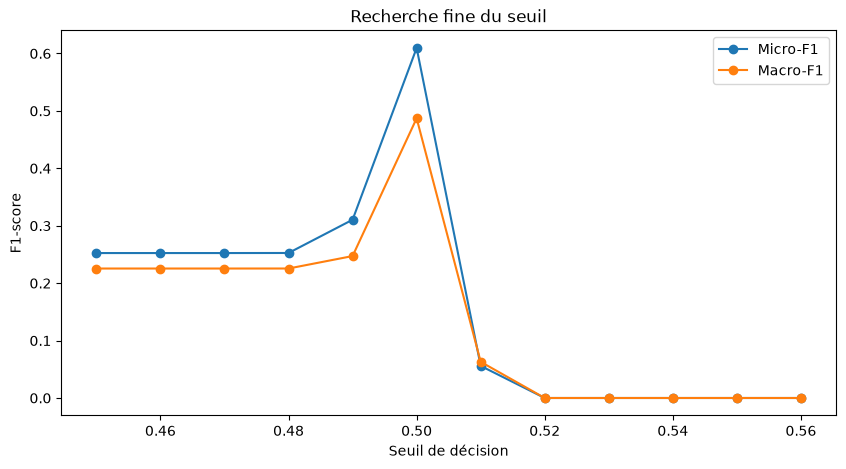

In [254]:
resultats_seuils_fins.plot(x="Seuil", y=["Micro-F1", "Macro-F1"], 
                           marker="o", figsize=(10, 5))

plt.title("Recherche fine du seuil")
plt.xlabel("Seuil de décision")
plt.ylabel("F1-score")
plt.show()

### Application du seuil sur le jeu de test

In [255]:
proba_test_lr_opt = modele_lr_opt_aspects.predict_proba(X_test_tfidf)

y_pred_lr_seuil = (proba_test_lr_opt >= seuil_optimal).astype(int)

print("Micro-F1 avec seuil :", round(f1_score(y_test, y_pred_lr_seuil, average="micro"), 3))

print("Macro-F1 avec seuil :", round(f1_score(y_test, y_pred_lr_seuil, average="macro"), 3))

Micro-F1 avec seuil : 0.615
Macro-F1 avec seuil : 0.524


### Résultat de l'optimisation du seuil

La recherche du seuil indique que le seuil **0,50** obtient le meilleur Macro-F1 sur le jeu de validation, avec un score de **0,487**.

Ce seuil correspond au seuil par défaut de la régression logistique. L'optimisation du seuil n'a donc pas modifié la règle de décision du modèle.

Appliqué au jeu de test, le modèle obtient :

- Micro-F1 : **0,615** ;
- Macro-F1 : **0,524**.

Le seuil de **0,50** est donc conservé pour la suite.

In [256]:
comparaison_modeles = pd.DataFrame({"Modèle": ["Régression logistique optimisée",
                                               "Régression logistique initiale",
                                               "SVM initial", "XGBoost initial"],
                                    "Micro-F1": [f1_score(y_test, y_pred_lr_opt_aspects, average="micro"),
                                                 f1_score(y_test, y_pred_lr, average="micro"),
                                                 f1_score(y_test, y_pred_svm, average="micro"),
                                                 f1_score(y_test, y_pred_xgb, average="micro")],
                                    "Macro-F1": [f1_score(y_test, y_pred_lr_opt_aspects, average="macro"),
                                                 f1_score(y_test, y_pred_lr, average="macro"),
                                                 f1_score(y_test, y_pred_svm, average="macro"),
                                                 f1_score(y_test, y_pred_xgb, average="macro")]})
# Ajout dummy
comparaison_modeles = pd.concat([comparaison_modeles,
                                 comparaison_dummy],
                                ignore_index=True)

display(comparaison_modeles.round(3))

,Modèle,Micro-F1,Macro-F1
0,Régression logistique optimisée,0.615,0.524
1,Régression logistique initiale,0.667,0.481
2,SVM initial,0.648,0.443
3,XGBoost initial,0.648,0.477
4,Dummy stratifié,0.307,0.140


### Comparaison finale des modèles
### Comparaison des modèles après optimisation de la régression logistique
Les performances finales des modèles sont les suivantes :

| Modèle | Micro-F1 | Macro-F1 |
|---|---:|---:|
| Régression logistique optimisée | 0,615 | 0,524 |
| Régression logistique initiale | 0,667 | 0,481 |
| SVM initial | 0,648 | 0,443 |
| XGBoost initial | 0,648 | 0,477 |
| Dummy stratifié | 0,307 | 0,140 |


La **régression logistique optimisée est retenue parmi les modèles classiques**. Elle obtient le meilleur **Macro-F1 de cette comparaison, avec 0,524**, conformément au critère choisi pour accorder le même poids aux 18 aspects.

L'optimisation fait progresser le Macro-F1 de **0,481 à 0,524**.
L'analyse par aspect montre notamment une amélioration de la détection de plusieurs classes rares, même si certains aspects enregistrent une baisse de performance.

Cette amélioration s'accompagne toutefois d'une diminution du Micro-F1, qui passe de **0,667 à 0,615**. La configuration initiale conserve donc un avantage sur cette métrique globale.

Le SVM et XGBoost initiaux obtiennent un Micro-F1 de **0,648**, mais leurs Macro-F1, respectivement **0,443** et **0,477**, restent inférieurs à celui de la régression logistique optimisée.

Le choix de cette dernière constitue ainsi un **compromis en faveur du Macro-F1**. Il doit être nuancé par la faible précision sur certains aspects et les petits effectifs de plusieurs classes dans le test.
La régression logistique initiale reste une référence utile pour son meilleur Micro-F1.

Enfin, les quatre configurations dépassent la référence naïve du dummy : **Micro-F1 = 0,307** et **Macro-F1 = 0,140**.

### Sauvegarde du modèle retenu

Nous enregistrons la régression logistique optimisée, déjà entraînée sur les 1 600 avis d'entraînement.

Cette sauvegarde permettra de réutiliser le modèle sans relancer la recherche d'hyperparamètres ni l'entraînement.

Pour prédire les aspects de nouveaux avis, nous utiliserons ensemble :

- le vectoriseur `tfidf`, déjà enregistré ;
- le modèle `modele_lr_opt_aspects` ;
- `liste_aspects`, déjà enregistrée, qui indique l'ordre des aspects prédits.

Le seuil retenu étant de 0,50, nous conservons la méthode `predict()` utilisée précédemment.

In [257]:
# Enregistrer le modèle optimisé déjà entraîné
joblib.dump(modele_lr_opt_aspects,"../models/modele_lr_opt_aspects.joblib")

print("Modèle LR optimisé enregistré.")

Modèle LR optimisé enregistré.


In [140]:
# Recharger le modèle optimisé déjà entraîné modele_lr_opt_aspects
modele_lr_opt_aspects = joblib.load("../models/modele_lr_opt_aspects.joblib")

## Évaluation séparée sur les tests GOLD et SILVER

Les scores précédents ont été calculés sur les 400 avis du test, qui regroupent 200 avis GOLD et 200 avis SILVER.

Nous séparons maintenant leur évaluation pour observer les performances selon l'origine des annotations.

Les modèles restent ceux déjà entraînés sur les 1 600 avis.
Seules les lignes utilisées pour calculer les scores changent :

- **Test GOLD** : comparaison des prédictions aux annotations GOLD ;
- **Test SILVER** : comparaison des prédictions aux annotations produites
  par le LLM.

Les scores sur SILVER mesurent donc l'accord avec les annotations du LLM.
Ils doivent être distingués des résultats obtenus sur GOLD.

Nous conservons le Micro-F1 et le Macro-F1 pour comparer les modèles.
Le dummy est également évalué sur les deux sous-ensembles.

In [260]:
# Repérer les avis GOLD et SILVER dans le jeu de test
masque_gold = test_400["type_annotation"] == "gold"
masque_silver = test_400["type_annotation"] == "silver"

# Séparer les annotations du test selon leur origine
y_test_gold = y_test.loc[masque_gold]
y_test_silver = y_test.loc[masque_silver]

print("TEST GOLD :", len(y_test_gold))
print("TEST SILVER :", len(y_test_silver))

TEST GOLD : 200
TEST SILVER : 200


In [265]:
# Réutiliser les prédictions déjà calculées sur les 400 avis du test
predictions_modeles = {
    "Régression logistique optimisée": y_pred_lr_opt_aspects,
    "Régression logistique initiale": y_pred_lr,
    "SVM initial": y_pred_svm,
    "XGBoost initial": y_pred_xgb,
    "Dummy stratifié": y_pred_dummy}

resultats_gold_silver = []

for nom_modele, predictions in predictions_modeles.items():

    # Sélectionner les prédictions correspondant à chaque groupe
    predictions_gold = predictions[masque_gold.to_numpy()]
    predictions_silver = predictions[masque_silver.to_numpy()]

    # Calculer les scores séparément sur GOLD et SILVER
    resultats_gold_silver.append({"Modèle": nom_modele,
                                  # Scores sur l'ensemble du test : 200 GOLD + 200 SILVER
                                  "Micro-F1 global": f1_score(
                                      y_test, predictions,
                                      average="micro", zero_division=0),
                                  "Micro-F1 GOLD": f1_score(
                                      y_test_gold, predictions_gold,
                                      average="micro", zero_division=0),
                                  "Micro-F1 SILVER": f1_score(
                                      y_test_silver, predictions_silver,
                                      average="micro", zero_division=0),
                                  "Macro-F1 global": f1_score(
                                      y_test, predictions,
                                      average="macro", zero_division=0),
                                  "Macro-F1 GOLD": f1_score(
                                      y_test_gold, predictions_gold,
                                      average="macro", zero_division=0),
                                  "Macro-F1 SILVER": f1_score(
                                      y_test_silver, predictions_silver,
                                      average="macro", zero_division=0)})

# Regrouper les résultats dans un tableau
evaluation_gold_silver = pd.DataFrame(resultats_gold_silver)

display(evaluation_gold_silver.round(3))

,Modèle,Micro-F1 global,Micro-F1 GOLD,Micro-F1 SILVER,Macro-F1 global,Macro-F1 GOLD,Macro-F1 SILVER
0,Régression logistique optimisée,0.615,0.613,0.616,0.524,0.510,0.526
1,Régression logistique initiale,0.667,0.673,0.661,0.481,0.504,0.464
2,SVM initial,0.648,0.645,0.650,0.443,0.468,0.425
3,XGBoost initial,0.648,0.656,0.640,0.477,0.509,0.439
4,Dummy stratifié,0.307,0.311,0.304,0.140,0.145,0.132


In [262]:
# Enregistrer les résultats pour les réutiliser dans le rapport
joblib.dump(evaluation_gold_silver,"../models/evaluation_gold_silver_aspects.joblib")

['../models/evaluation_gold_silver_aspects.joblib']

### Analyse des résultats globaux et séparés GOLD / SILVER

La régression logistique optimisée obtient le meilleur Macro-F1 observé sur le test complet (**0,524**), ainsi que sur GOLD (**0,510**) et SILVER (**0,526**).

Cependant, le gain par rapport à la régression logistique initiale varie selon le sous-ensemble :

- **Test complet** : de 0,481 à 0,524, soit **+0,043** ;
- **GOLD** : de 0,504 à 0,510, soit **+0,006** ;
- **SILVER** : de 0,464 à 0,526, soit **+0,062**.

Après optimisation, les Macro-F1 obtenus sur GOLD et SILVER sont proches : respectivement **0,510 et 0,526**.

Cependant, le gain apporté par l’optimisation est plus marqué sur SILVER (**+0,062**) que sur GOLD (**+0,006**), car la LR initiale obtenait un score plus faible sur SILVER.

L’optimisation s’accompagne également d’une baisse du Micro-F1, sur le test complet comme sur chacun des deux groupes.
La régression logistique initiale conserve le meilleur Micro-F1 :
**0,667 au global**, **0,673 sur GOLD** et **0,661 sur SILVER**.

Les quatre configurations entraînées sur les textes dépassent le dummy sur les deux métriques, au global et dans chaque sous-ensemble.

### Points de vigilance

Le choix de la LR optimisée répond au critère du Macro-F1 retenu pour l’optimisation. Cette évaluation montre toutefois que son bénéfice est faible sur GOLD et plus important dans l’accord avec les annotations SILVER produites par le LLM.

Les différences entre GOLD et SILVER ne peuvent pas être attribuées uniquement à la qualité des annotations : les avis et les fréquences des aspects diffèrent entre les deux groupes. Chaque sous ensemble contient seulement 200 avis ; les scores des aspects rares restent sensibles à quelques erreurs.

Enfin, les F1 globaux sont recalculés sur l’ensemble des 400 avis. Ils ne correspondent pas nécessairement à la moyenne des F1 GOLD et SILVER, même si les deux groupes ont la même taille.

## Interprétation de la régression logistique par aspect

Pour comprendre sur quels termes s’appuie le modèle, nous examinons les coefficients appris par la régression logistique optimisée.

Chaque aspect possède son propre classifieur et un coefficient pour chaque variable TF-IDF, correspondant à un mot ou à un groupe de deux mots.

- Un **coefficient positif** contribue en faveur de la présence de l’aspect.
- Un **coefficient négatif** contribue en faveur de son absence.

Nous affichons, pour chacun des 18 aspects, les **dix termes dont les coefficients positifs sont les plus élevés**.

Cette analyse utilise les coefficients déjà appris : aucun nouvel entraînement n’est nécessaire.

In [296]:
# Récupérer les termes dans l'ordre des colonnes du TF-IDF
termes = tfidf.get_feature_names_out()

# Conserver les résultats des 18 aspects
resultats_coefficients = []

for i, aspect in enumerate(liste_aspects):

    # Récupérer le classifieur entraîné pour cet aspect
    clf = modele_lr_opt_aspects.estimators_[i]

    # Récupérer le coefficient associé à chaque terme
    coefficients = clf.coef_[0]

    # Associer les termes à leurs coefficients
    tableau_coefficients = pd.DataFrame({"Aspect": aspect,
                                         "Terme": termes,
                                         "Coefficient": coefficients})

    # Garder les coefficients positifs
    tableau_coefficients = tableau_coefficients[tableau_coefficients["Coefficient"] > 0]

    # Trier du coefficient le plus élevé au plus faible
    tableau_coefficients = tableau_coefficients.sort_values("Coefficient", ascending=False)

    # Sélectionner les dix premiers termes
    top_termes = tableau_coefficients.head(10)

    # Conserver et afficher les résultats de cet aspect
    resultats_coefficients.append(top_termes)

    print("\nAspect :", aspect)
    display(top_termes[["Terme", "Coefficient"]].round(4))

# Regrouper les résultats des 18 aspects
termes_coefficients_lr_aspects = pd.concat(resultats_coefficients,
                                    ignore_index=True)

# Enregistrer le tableau contenant coeff positifs fort
os.makedirs("../models", exist_ok=True)

joblib.dump(termes_coefficients_lr_aspects,"../models/termes_coefficients_lr_aspects.joblib")
print("Coefficients de la LR par aspect enregistrés.")


Aspect : accessibility


,Terme,Coefficient
2346,car,0.0934
3479,disabled,0.0703
2350,car park,0.0643
8809,park,0.0624
12523,to,0.0621
5786,in,0.0605
13817,we,0.0585
8988,pickup,0.0583
13175,up,0.0565
10878,staff,0.0535



Aspect : app


,Terme,Coefficient
1114,app,0.2423
225,account,0.1313
11509,the app,0.1065
12523,to,0.0973
6869,log,0.0846
12826,to use,0.0792
13266,use,0.0651
2640,code,0.0645
8372,online,0.0643
4840,get,0.0544



Aspect : booking


,Terme,Coefficient
1940,booking,0.1164
1931,booked,0.0777
1923,book,0.0668
12523,to,0.0650
12560,to book,0.0622
3750,easy,0.0440
13817,we,0.0400
12431,ticket,0.0380
1139,appointment,0.0368
13542,was,0.0359



Aspect : cleanliness


,Terme,Coefficient
2577,clean,0.1665
4711,friendly,0.1024
3475,dirty,0.1021
4366,filthy,0.0849
14523,wow,0.0755
4495,food,0.0740
2954,could do,0.0721
5629,house,0.0708
639,and,0.0699
13817,we,0.0684



Aspect : communication


,Terme,Coefficient
2710,communication,0.0747
11484,the,0.0453
12523,to,0.0436
3812,email,0.0393
11392,that,0.0359
7832,not,0.0343
13542,was,0.0294
7099,me,0.0292
8492,order,0.0291
4721,from,0.0272



Aspect : customer service


,Terme,Coefficient
10351,service,0.1080
3060,customer,0.0863
3070,customer service,0.0729
12523,to,0.0467
12181,they,0.0415
2730,company,0.0346
7454,my,0.0328
11484,the,0.0317
12074,them,0.0295
9939,response,0.0289



Aspect : delivery


,Terme,Coefficient
3279,delivery,0.1657
8492,order,0.0940
1249,arrived,0.0712
3257,delivered,0.0592
8538,ordered,0.0478
3155,days,0.0409
6399,item,0.0363
7558,my order,0.0341
11815,the order,0.0325
11613,the delivery,0.0324



Aspect : environment


,Terme,Coefficient
13817,we,0.1470
11484,the,0.1373
4495,food,0.0964
13542,was,0.0954
13979,were,0.0796
6945,lovely,0.0760
6098,is,0.0681
639,and,0.0606
13875,we were,0.0585
4509,for,0.0582



Aspect : packaging


,Terme,Coefficient
8753,packaging,0.1442
8748,packaged,0.1401
1990,box,0.1163
13954,well packaged,0.1081
13938,well,0.0985
3279,delivery,0.0964
1249,arrived,0.0877
13542,was,0.0752
3094,damaged,0.0746
8757,packed,0.0688



Aspect : payment


,Terme,Coefficient
8883,payment,0.0984
8861,pay,0.0698
7314,money,0.0665
8890,payments,0.0579
1881,bill,0.0542
8770,paid,0.0538
5292,have,0.0481
225,account,0.0418
1562,balance,0.0393
2353,card,0.0389



Aspect : price


,Terme,Coefficient
9192,price,0.1007
4114,expensive,0.0427
11484,the,0.0390
4509,for,0.0371
9212,prices,0.0330
4980,good,0.0316
11864,the price,0.0303
7314,money,0.0296
12181,they,0.0289
8770,paid,0.0284



Aspect : product


,Terme,Coefficient
11484,the,0.0584
9469,quality,0.0503
5064,great,0.0378
6246,it,0.0370
9291,product,0.0344
4980,good,0.0303
4495,food,0.0260
6098,is,0.0254
9316,products,0.0254
2995,course,0.0236



Aspect : refund


,Terme,Coefficient
9749,refund,0.2887
9772,refunded,0.0648
12523,to,0.0642
7832,not,0.0628
12181,they,0.0619
11897,the refund,0.0549
4601,for refund,0.0517
7314,money,0.0436
12074,them,0.0433
7099,me,0.0427



Aspect : replacement


,Terme,Coefficient
9857,replacement,0.2395
2053,broken,0.1567
3094,damaged,0.0756
10324,sent,0.0719
6399,item,0.0650
12181,they,0.0566
8753,packaging,0.0562
2875,contacted,0.0550
8146,of replacement,0.0543
4277,fault,0.0536



Aspect : return


,Terme,Coefficient
9990,return,0.2298
10004,returns,0.1483
12756,to return,0.1228
9999,returned,0.0990
3861,en,0.0822
9125,postage,0.0731
12887,too,0.0704
6759,light,0.0668
4935,gloves,0.0614
1956,boots,0.0586



Aspect : staff


,Terme,Coefficient
10878,staff,0.0753
639,and,0.0675
5469,helpful,0.0649
5402,he,0.0631
13542,was,0.0493
8607,our,0.0447
9330,professional,0.0434
10471,she,0.0427
11484,the,0.0392
5492,her,0.0377



Aspect : trustworthiness


,Terme,Coefficient
12181,they,0.0871
14587,you,0.0580
12523,to,0.0544
12304,this,0.0534
2730,company,0.0508
7832,not,0.0498
12040,their,0.0480
1158,are,0.0430
3600,don,0.0400
6098,is,0.0389



Aspect : website


,Terme,Coefficient
13889,website,0.1808
3750,easy,0.1263
3761,easy to,0.0995
12026,the website,0.0874
8492,order,0.0627
12708,to order,0.0527
6098,is,0.0483
10592,site,0.0465
13266,use,0.0440
8559,ordering,0.0419


Coefficients de la LR par aspect enregistrés.


### Visualisation des principaux coefficients par aspect

Pour chaque aspect, nous représentons les dix termes aux coefficients positifs les plus élevés.

La longueur de chaque barre correspond au coefficient appris.
Les termes sont classés pour placer le coefficient le plus élevé en haut du graphique.

Ces coefficients indiquent les poids associés aux termes dans le modèle ; ils ne représentent pas des probabilités.

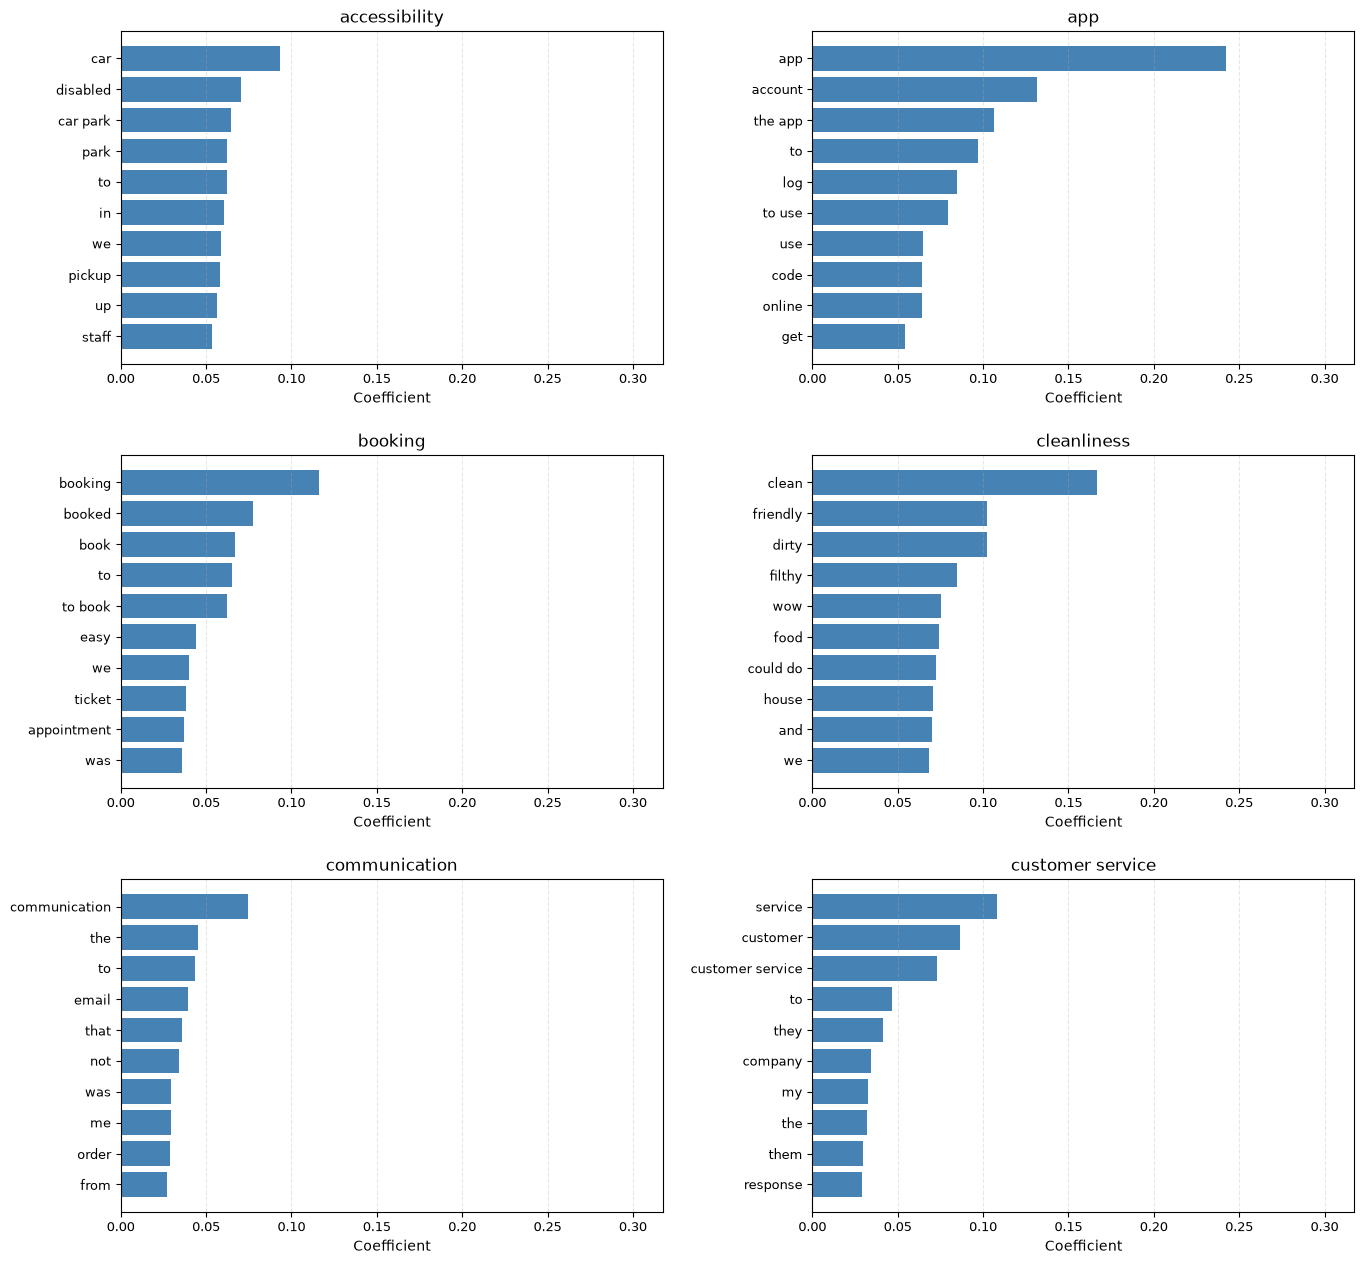

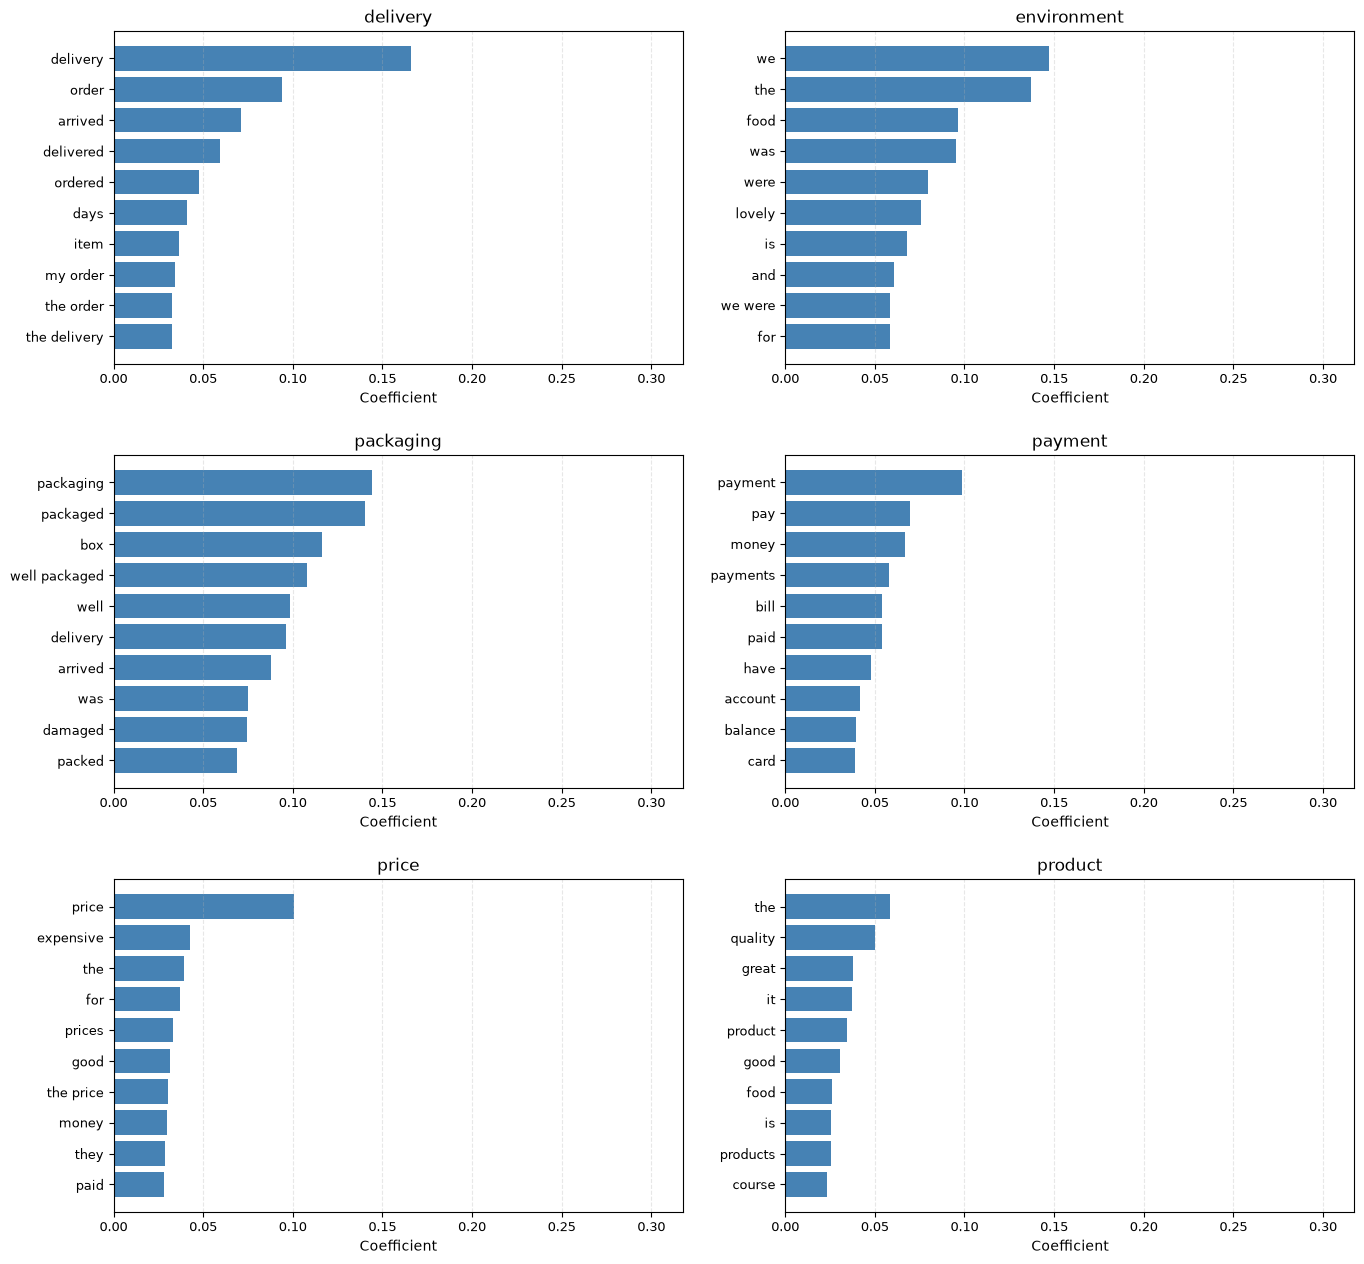

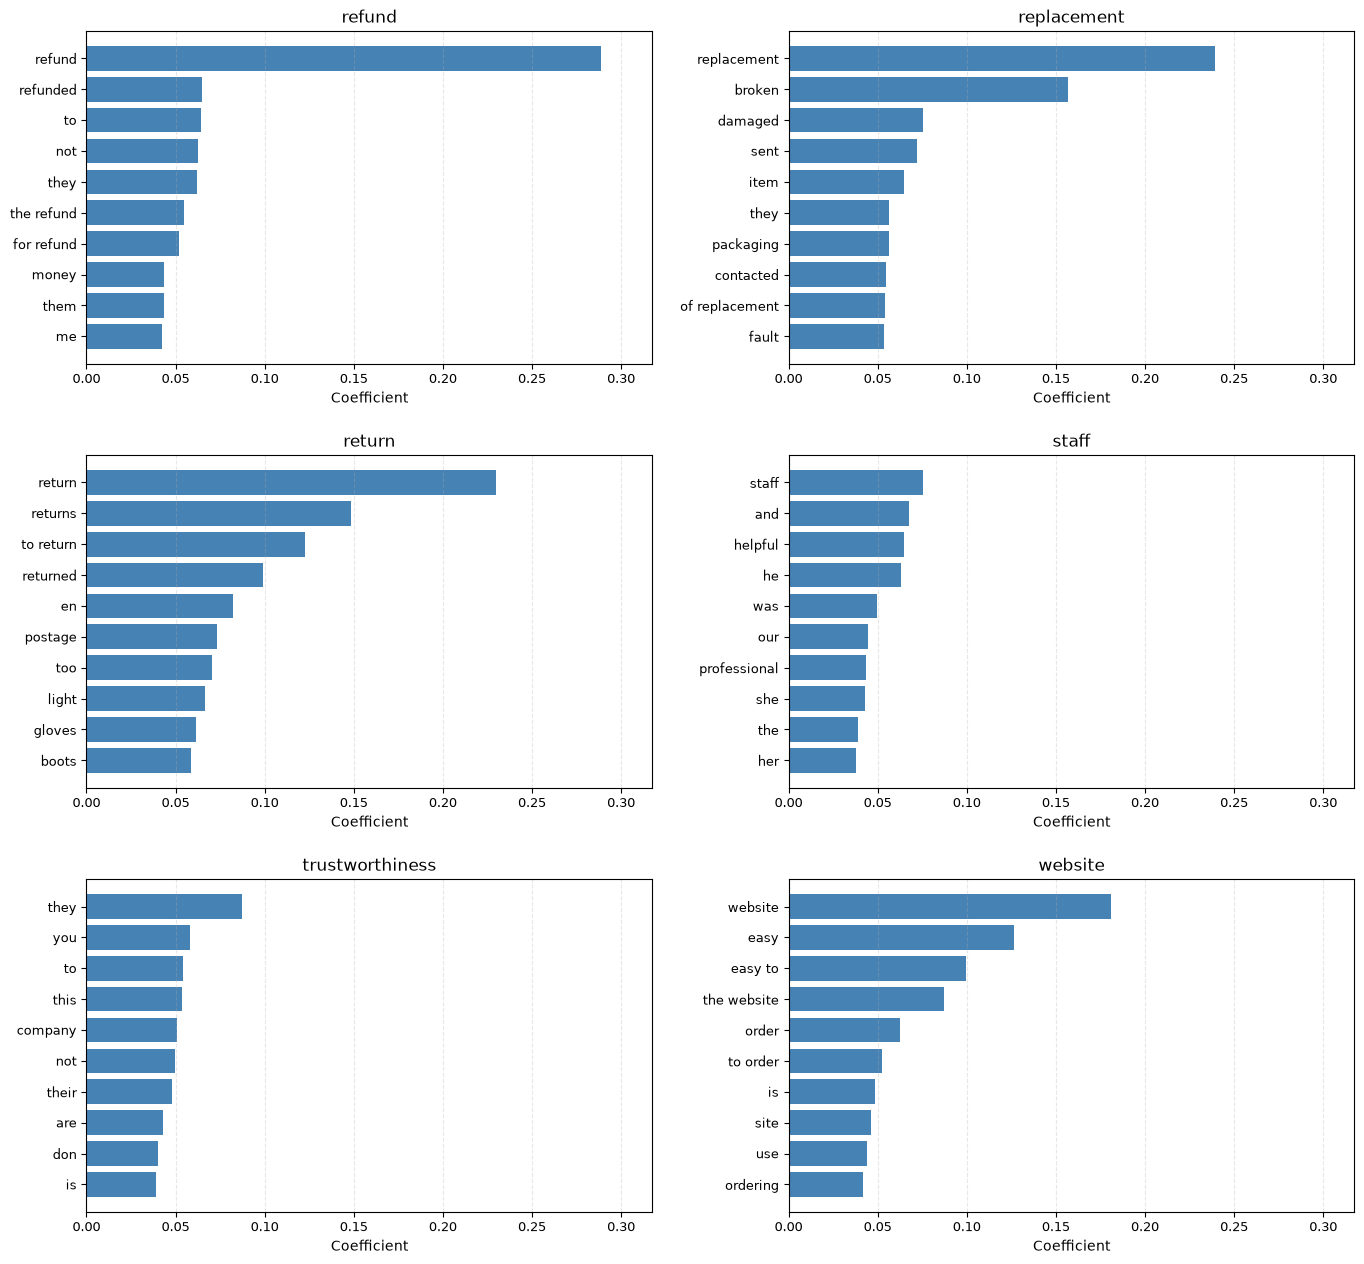

In [297]:
# Créer le dossier de sauvegarde des figures
os.makedirs("../figures", exist_ok=True)

# Utiliser la même échelle horizontale pour tous les graphiques
limite_x = termes_coefficients_lr_aspects["Coefficient"].max() * 1.1

# Regrouper les aspects par six : trois figures pour les 18 aspects
for debut in range(0, len(liste_aspects), 6):

    plt.figure(figsize=(14, 13))

    # Sélectionner les six aspects de cette figure
    aspects_figure = liste_aspects[debut:debut + 6]

    for position, aspect in enumerate(aspects_figure):

        # Organiser la figure en trois lignes et deux colonnes
        plt.subplot(3, 2, position + 1)

        # Récupérer les dix termes déjà sélectionnés pour cet aspect
        top_termes = termes_coefficients_lr_aspects[termes_coefficients_lr_aspects["Aspect"] == aspect]

        # Placer le coefficient le plus élevé en haut
        top_termes = top_termes.sort_values("Coefficient", ascending=True)

        # Représenter les coefficients par des barres horizontales
        plt.barh(top_termes["Terme"],
                 top_termes["Coefficient"],
                 color="steelblue")

        plt.title(aspect, fontsize=12)
        plt.xlabel("Coefficient")
        plt.xlim(0, limite_x)
        plt.xticks(fontsize=9)
        plt.yticks(fontsize=9)
        plt.grid(axis="x", linestyle="--", alpha=0.3)

    # Ajuster l'espacement entre les graphiques
    plt.tight_layout(pad=2)

    # Enregistrer chaque figure
    numero_figure = debut // 6 + 1

    plt.savefig(f"../figures/termes_coefficients_lr_aspects_{numero_figure}.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()
    plt.close()

### Lecture et limites des coefficients

Les termes affichés sont ceux auxquels le modèle attribue les coefficients positifs les plus élevés pour chaque aspect. Le mot « positif » désigne ici le signe du coefficient, et non le sentiment exprimé dans l’avis.

Un coefficient n’est pas une probabilité. Dans un avis donné, la contribution d’un terme au score du classifieur dépend du produit :

**coefficient du terme × valeur TF-IDF du terme dans cet avis**.

Les prédictions dépendent de l’ensemble des termes et de l’interception du modèle. La présence d’un terme de ce tableau ne suffit donc pas à garantir la détection de l’aspect.

Cette analyse décrit les associations apprises sur notre corpus. Elle ne démontre pas une relation causale et ne fournit pas, à elle seule, l’explication complète d’une prédiction particulière.

Cette sélection permet d’examiner les associations apprises par le modèle. Elle concerne uniquement l’affichage : **le modèle continue d’utiliser l’ensemble des variables TF-IDF pour ses prédictions**.

#### Des associations cohérentes pour plusieurs aspects

Plusieurs classements font ressortir un vocabulaire directement lié à l’aspect recherché :

| Aspect | Exemples de termes sélectionnés |
|---|---|
| `delivery` | `delivery`, `order`, `arrived`, `delivered` |
| `booking` | `booking`, `booked`, `book`, `to book` |
| `packaging` | `packaging`, `packaged`, `box`, `well packaged` |
| `payment` | `payment`, `pay`, `money`, `payments` |
| `customer service` | `service`, `customer`, `customer service` |
| `website` | `website`, `easy`, `easy to`, `the website` |

Pour `refund`, le terme `refund` possède un coefficient de **0,2887**, nettement supérieur à celui de `refunded` (**0,0648**). Le modèle attribue donc un poids particulièrement élevé à ce terme parmi les variables de ce classifieur. Cela ne signifie toutefois pas que sa seule présence suffit à déterminer la prédiction.

Pour `cleanliness`, les termes `clean`, `dirty` et `filthy` figurent parmi les coefficients positifs les plus élevés. Ce résultat est cohérent avec notre tâche : **détecter que l’avis parle de propreté**, que l’appréciation soit favorable ou défavorable.

#### Des associations moins spécifiques à examiner

Certains aspects font ressortir davantage de mots génériques. Pour `environment`, les premiers termes sont `we` et `the`. Pour `trustworthiness`, il s’agit de `they` et `you`. Le mot `the` arrive également en tête pour `product`.

Ces mots donnent une explication moins directe de la détection de l’aspect. Leur présence constitue un point de vigilance, mais elle ne démontre pas, à elle seule, qu’ils provoquent les erreurs du modèle.

D’autres associations peuvent être liées au contexte des avis. Par exemple, `delivery` apparaît dans le classement de `packaging`. Cela pourrait refléter des avis mentionnant simultanément la livraison et l’emballage. Cette hypothèse demanderait une vérification dans les textes concernés.

La suppression de certains mots génériques constitue donc une piste à tester sur une validation issue du train. Les graphiques seuls ne permettent pas d’affirmer que cette modification améliorerait les performances.

#### Limites de cette analyse

- Un coefficient positif favorise la présence de l’aspect ; il ne représente ni une probabilité ni un sentiment positif.
- La contribution d’un terme dépend du **produit de son coefficient par sa valeur TF-IDF** dans l’avis. La prédiction combine toutes les contributions et la constante du modèle.
- Les figures montrent uniquement les coefficients positifs sélectionnés. Les coefficients négatifs, également utilisés par le modèle, ne sont pas représentés.
- Des termes apparemment pertinents ne garantissent pas une bonne précision ou un bon rappel. Cette interprétation complète l’évaluation par aspect, sans expliquer à elle seule toutes les erreurs observées.

In [299]:
# Charger le tableau sauvegardé sans modifier le tableau en mémoire
coefficients_enregistres = joblib.load("../models/termes_coefficients_lr_aspects.joblib")

print("Nombre total de lignes :", len(coefficients_enregistres))

# Compter les termes enregistrés pour chaque aspect
display(coefficients_enregistres.groupby("Aspect").size())

Nombre total de lignes : 180


Aspect
accessibility       10
app                 10
booking             10
cleanliness         10
communication       10
customer service    10
delivery            10
environment         10
packaging           10
payment             10
price               10
product             10
refund              10
replacement         10
return              10
staff               10
trustworthiness     10
website             10
dtype: int64

In [300]:
modele_lr_opt_aspects.estimators_[i].coef_[0]

array([-0.00069383, -0.00092241,  0.01074259, ..., -0.00144316,
       -0.00077778, -0.00141861], shape=(14705,))

In [301]:
# Choisir l'aspect et retrouver son classifieur // EXMPLE POUR RECUP LES COEF ET TERMES ASSOCIé
aspect = "delivery"
i = liste_aspects.index(aspect)

# Récupérer les termes et les coefficients dans le même ordre
termes = tfidf.get_feature_names_out()
coefficients = modele_lr_opt_aspects.estimators_[i].coef_[0]

# Associer chaque terme à son coefficient
tableau_coefficients = pd.DataFrame({"Aspect": aspect,
                                     "Terme": termes,
                                     "Coefficient": coefficients})

display(tableau_coefficients.sort_values("Coefficient", ascending=False))

display(tableau_coefficients[tableau_coefficients["Coefficient"] < 0]
    .sort_values("Coefficient", ascending=True)
    .head(20))

,Aspect,Terme,Coefficient
3279,delivery,delivery,0.165702
8492,delivery,order,0.094026
1249,delivery,arrived,0.071163
3257,delivery,delivered,0.059165
8538,delivery,ordered,0.047751
...,...,...,...
6098,delivery,is,-0.021574
7099,delivery,me,-0.021806
10878,delivery,staff,-0.023172
10471,delivery,she,-0.024072


,Aspect,Terme,Coefficient
12523,delivery,to,-0.036822
10471,delivery,she,-0.024072
10878,delivery,staff,-0.023172
7099,delivery,me,-0.021806
6098,delivery,is,-0.021574
2995,delivery,course,-0.020094
13817,delivery,we,-0.019961
14295,delivery,with,-0.018566
5492,delivery,her,-0.018496
5402,delivery,he,-0.016812


## Prédire les aspects d'un nouvel avis

Nous rechargeons le vectoriseur TF-IDF, le modèle optimisé et la liste ordonnée des aspects.

Le nouvel avis est transformé avec le TF-IDF déjà appris, sans nouvel entraînement. Le modèle prédit ensuite la présence ou l'absence de chacun des 18 aspects.

La fonction retourne les noms des aspects pour lesquels la prédiction vaut 1.

In [258]:
def predire_aspects_ml(texte):
    # Transformer l'avis avec le vectoriseur déjà appris
    texte_tfidf = tfidf.transform([texte])

    # Prédire la présence ou l'absence de chaque aspect
    prediction = modele_lr_opt_aspects.predict(texte_tfidf)[0]

    # Retourner les noms des aspects prédits comme présents
    return [liste_aspects[i]
        for i, valeur in enumerate(prediction)
        if valeur == 1]

In [259]:
avis_test = ("The delivery was very late, but the customer service "
             "was excellent and very helpful.")

predire_aspects_ml(avis_test)

['customer service', 'delivery', 'staff']

**Entraîner la LR optimisée sur ce sous-train**

**Récupérer les probabilités**

# Bonus
## Exploration complémentaire - Optimisation de XGBoost

Cette exploration teste l'effet d'un réglage des hyperparamètres de XGBoost. Elle est conservée pour documenter les essais réalisés, mais n'est pas intégrée à la comparaison principale ni au rapport.

### Optimisation de XGBoost avec RandomizedSearchCV

Les premiers résultats de XGBoost sont suffisamment proches de ceux de la Régression Logistique pour justifier une optimisation de ses principaux hyperparamètres.

Contrairement à GridSearchCV, qui teste toutes les combinaisons définies, **RandomizedSearchCV** sélectionne aléatoirement un nombre limité de combinaisons. Cette approche permet d'explorer un espace de paramètres plus large tout en limitant le temps de calcul.

Trois hyperparamètres sont étudiés :

- `n_estimators` : nombre d'arbres construits ;
- `learning_rate` : contribution de chaque nouvel arbre à l'apprentissage ;
- `max_depth` : profondeur maximale de chaque arbre.

Un `learning_rate` faible produit un apprentissage plus progressif et peut nécessiter davantage d'arbres, tandis qu'une profondeur élevée augmente la complexité du modèle et peut favoriser le surapprentissage.


In [47]:
#modele_xgb_cv = OneVsRestClassifier(XGBClassifier(objective="binary:logistic", eval_metric="logloss", 
#                                                  random_state=42, n_jobs=1))

#parametres_xgb = {"estimator__n_estimators": [100, 200, 300, 500], 
#                  "estimator__learning_rate": [0.03, 0.05, 0.1, 0.2, 0.3],
#                  "estimator__max_depth": [2, 3, 4, 6]}

#random_xgb = RandomizedSearchCV(modele_xgb_cv, param_distributions=parametres_xgb, n_iter=20, 
#                                scoring="f1_macro", cv=5, random_state=42, n_jobs=-1)

#random_xgb.fit(X_train_tfidf, y_train)

#print("Meilleurs paramètres :", random_xgb.best_params_)
#print("Meilleur Macro-F1 CV :", round(random_xgb.best_score_, 3))

Meilleurs paramètres : {'estimator__n_estimators': 200, 'estimator__max_depth': 2, 'estimator__learning_rate': 0.2}
Meilleur Macro-F1 CV : 0.471


In [48]:
#modele_xgb_opt = OneVsRestClassifier(XGBClassifier(n_estimators=200, learning_rate=0.2, max_depth=2, objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=1))

#modele_xgb_opt.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.","XGBClassifier...ree=None, ...)"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](18,)","[ 0, 1, 2,...,15,16,17]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), XGBClassifier...ree=None, ...), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,18
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,14705
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None


### Résultat de l'optimisation de XGBoost

La recherche aléatoire retient la combinaison suivante :

- `n_estimators = 200`
- `max_depth = 2`
- `learning_rate = 0.2`

Le meilleur Macro-F1 moyen obtenu en validation croisée est de **0,471**.

Par rapport au modèle initial, le modèle optimisé utilise davantage d'arbres mais avec une profondeur plus faible. Il construit donc un plus grand nombre de modèles simples plutôt qu'un nombre plus faible d'arbres plus complexes.

Cette configuration doit maintenant être évaluée sur le jeu de test afin de déterminer si l'optimisation améliore réellement les performances de XGBoost.

In [51]:
modele_xgb_opt = joblib.load("../models/xgb_aspects_opt.joblib")

In [49]:
y_pred_xgb_opt = modele_xgb_opt.predict(X_test_tfidf)

print("Micro-F1 XGBoost initial :", round(f1_score(y_test, y_pred_xgb, average="micro"), 3))

print("Micro-F1 XGBoost optimisé :", round(f1_score(y_test, y_pred_xgb_opt, average="micro"), 3))

print()

print("Macro-F1 XGBoost initial :", round(f1_score(y_test, y_pred_xgb, average="macro"), 3))

print("Macro-F1 XGBoost optimisé :", round(f1_score(y_test, y_pred_xgb_opt, average="macro"), 3))

Micro-F1 XGBoost initial : 0.648
Micro-F1 XGBoost optimisé : 0.652

Macro-F1 XGBoost initial : 0.477
Macro-F1 XGBoost optimisé : 0.49


### Sauvegarde du modèle XGBoost optimisé

Le modèle XGBoost optimisé est sauvegardé après son entraînement afin de pouvoir être réutilisé ultérieurement sans relancer la recherche d'hyperparamètres ni l'entraînement.

In [50]:
# sauvegarde
#import joblib
#import os

#os.makedirs("../models", exist_ok=True)

# Enregistrer le modèle XGB optimisé déjà entraîné
#joblib.dump(modele_xgb_opt, "../models/xgb_aspects_opt.joblib")

#print("Modèle XGBoost optimisé et TF-IDF sauvegardés.")

Modèle XGBoost optimisé et TF-IDF sauvegardés.


In [ ]:
# Recharger le modèle XGB optimisé déjà entraîné
xgb_aspects_opt = joblib.load("../models/xgb_aspects_opt.joblib")

In [52]:
comparaison_modeles = pd.DataFrame({"Modèle": ["Logistic Regression initiale", "Logistic Regression optimisée", 
                                               "SVM", "XGBoost", "XGBoost optimisé"],
                                    "Micro-F1": [f1_score(y_test, y_pred_lr, average="micro"),
                                                 f1_score(y_test, y_pred_lr_opt_aspects, average="micro"),
                                                 f1_score(y_test, y_pred_svm, average="micro"),
                                                 f1_score(y_test, y_pred_xgb, average="micro"),
                                                 f1_score(y_test, y_pred_xgb_opt, average="micro")],
                                    "Macro-F1": [f1_score(y_test, y_pred_lr, average="macro"),
                                                 f1_score(y_test, y_pred_lr_opt_aspects, average="macro"),
                                                 f1_score(y_test, y_pred_svm, average="macro"),
                                                 f1_score(y_test, y_pred_xgb, average="macro"),
                                                 f1_score(y_test, y_pred_xgb_opt, average="macro")]})

comparaison_modeles[["Micro-F1", "Macro-F1"]] = (comparaison_modeles[["Micro-F1", "Macro-F1"]].round(3))

comparaison_modeles

,Modèle,Micro-F1,Macro-F1
0,Logistic Regression initiale,0.667,0.481
1,Logistic Regression optimisée,0.615,0.524
2,SVM,0.648,0.443
3,XGBoost,0.648,0.477
4,XGBoost optimisé,0.652,0.490


### Effet de l'optimisation de XGBoost

L'optimisation des hyperparamètres améliore les performances de XGBoost :

- Micro-F1 : de **0,648 à 0,652**
- Macro-F1 : de **0,477 à 0,490**

Le modèle optimisé utilise :

- `n_estimators = 200`
- `max_depth = 2`
- `learning_rate = 0.2`

Par rapport au modèle initial, le nombre d'arbres augmente tandis que leur profondeur diminue. Le modèle s'appuie ainsi sur davantage d'arbres simples, avec un apprentissage plus progressif.

Cette configuration permet d'améliorer simultanément le Micro-F1 et le Macro-F1, ce qui montre que le réglage des hyperparamètres a eu un effet positif sur XGBoost.

### Comparaison finale des modèles classiques

Les performances obtenues sur le jeu de test sont les suivantes :

| Modèle | Micro-F1 | Macro-F1 |
|---|---:|---:|
| Régression Logistique initiale | **0,667** | 0,481 |
| Régression Logistique optimisée | 0,615 | **0,524** |
| SVM | 0,648 | 0,443 |
| XGBoost initial | 0,648 | 0,477 |
| XGBoost optimisé | 0,652 | 0,490 |

Les résultats montrent qu'aucun modèle ne domine simultanément sur les deux métriques.

La **Régression Logistique initiale** obtient le meilleur Micro-F1 (`0,667`), ce qui traduit la meilleure performance globale sur l'ensemble des prédictions.

La **Régression Logistique optimisée** obtient le meilleur Macro-F1 (`0,524`). L'analyse précédente a montré que cette amélioration provient notamment d'une meilleure détection de plusieurs aspects minoritaires, au prix d'une diminution du Micro-F1.

L'optimisation de XGBoost améliore ses deux scores et lui permet d'atteindre un Macro-F1 de `0,490`, supérieur à celui de la Régression Logistique initiale (`0,481`). Il reste cependant inférieur à la Régression Logistique optimisée sur cette métrique et inférieur à la Régression Logistique initiale en Micro-F1.

La Régression Logistique reste donc particulièrement performante pour la détection multi-label des aspects à partir de la représentation TF-IDF, avec deux configurations correspondant à deux compromis différents entre performance globale et équilibre entre les classes.

### Analyse des erreurs par matrices de confusion

Les métriques Precision, Recall et F1 permettent de comparer les performances par aspect, mais elles ne montrent pas directement la nature des erreurs produites.

Pour compléter l'analyse, les prédictions sont décomposées en :

- **VP (Vrai Positive)** : aspect correctement détecté ;
- **VN (Vrai Negative)** : absence d'aspect correctement identifiée ;
- **FP (False Positive)** : aspect prédit alors qu'il est absent ;
- **FN (False Negative)** : aspect présent mais non détecté.

Afin de conserver une analyse lisible, quatre aspects représentatifs sont sélectionnés :

- `product` : aspect fréquent et globalement bien détecté ;
- `communication` : illustre le compromis entre précision et rappel ;
- `packaging` : aspect sur lequel XGBoost obtient de très bonnes performances ;
- `accessibility` : aspect rare et difficile à détecter.

### Évaluation détaillée par aspect

Les scores Micro-F1 et Macro-F1 donnent une vision globale des performances, mais ils ne permettent pas d'identifier précisément les aspects bien ou mal détectés.

Une analyse détaillée est donc réalisée pour les trois modèles les plus intéressants :

- Régression Logistique initiale ;
- Régression Logistique optimisée ;
- XGBoost optimisé.

Pour chacun des 18 aspects, trois métriques sont observées :

- **Precision** : parmi les aspects prédits comme présents, proportion réellement correcte ;
- **Recall** : parmi les aspects réellement présents, proportion détectée par le modèle ;
- **F1-score** : compromis entre précision et rappel.

Le support correspond au nombre d'avis du jeu de test contenant réellement l'aspect considéré.

In [81]:
rapport_lr = classification_report(y_test, y_pred_lr, target_names=liste_aspects, output_dict=True, zero_division=0)

rapport_lr_opt = classification_report(y_test, y_pred_lr_opt_aspects, target_names=liste_aspects, output_dict=True, 
                                       zero_division=0)

rapport_xgb_opt = classification_report(y_test, y_pred_xgb_opt, target_names=liste_aspects, output_dict=True, 
                                        zero_division=0)


evaluation_aspects = pd.DataFrame({"Aspect": liste_aspects, 
                                   "Precision LR": [rapport_lr[a]["precision"] for a in liste_aspects],
                                   "Recall LR": [rapport_lr[a]["recall"] for a in liste_aspects],
                                   "F1 LR": [rapport_lr[a]["f1-score"] for a in liste_aspects],
                                   "Precision LR opt": [rapport_lr_opt[a]["precision"] for a in liste_aspects],
                                   "Recall LR opt": [rapport_lr_opt[a]["recall"] for a in liste_aspects],
                                   "F1 LR opt": [rapport_lr_opt[a]["f1-score"] for a in liste_aspects],
                                   "Precision XGB opt": [rapport_xgb_opt[a]["precision"] for a in liste_aspects],
                                   "Recall XGB opt": [rapport_xgb_opt[a]["recall"] for a in liste_aspects],
                                   "F1 XGB opt": [rapport_xgb_opt[a]["f1-score"] for a in liste_aspects],
                                   "Support": [int(rapport_lr[a]["support"]) for a in liste_aspects]})

evaluation_aspects = evaluation_aspects.round(3)

display(evaluation_aspects)

,Aspect,Precision LR,Recall LR,F1 LR,Precision LR opt,Recall LR opt,F1 LR opt,Precision XGB opt,Recall XGB opt,F1 XGB opt,Support
0,accessibility,0.000,0.000,0.000,0.333,0.333,0.333,0.000,0.000,0.000,12
1,app,0.833,0.357,0.500,0.533,0.571,0.552,0.778,0.500,0.609,14
2,booking,0.625,0.417,0.500,0.325,0.694,0.442,0.789,0.417,0.545,36
3,cleanliness,0.333,0.125,0.182,0.455,0.625,0.526,0.750,0.375,0.500,8
4,communication,0.514,0.718,0.599,0.344,0.846,0.489,0.711,0.346,0.466,78
5,customer service,0.740,0.761,0.751,0.674,0.847,0.751,0.774,0.699,0.734,176
6,delivery,0.868,0.681,0.763,0.797,0.726,0.760,0.880,0.652,0.749,135
7,environment,0.200,0.154,0.174,0.167,0.462,0.245,0.000,0.000,0.000,13
8,packaging,0.632,0.706,0.667,0.378,0.824,0.519,0.867,0.765,0.812,17
9,payment,0.333,0.136,0.194,0.302,0.591,0.400,0.500,0.182,0.267,22


### Analyse détaillée des performances par aspect

L'analyse par aspect met en évidence des comportements différents selon les modèles.

La **Régression Logistique initiale** obtient des résultats solides sur plusieurs aspects fréquents, notamment `product` (F1 = 0,767), `delivery` (0,763), `customer service` (0,751) et `staff` (0,721). En revanche, elle ne détecte pas du tout `accessibility` et `replacement`.

La **Régression Logistique optimisée** améliore fortement la détection de plusieurs aspects minoritaires. Par exemple :

- `cleanliness` : F1 de 0,182 à 0,526 ;
- `accessibility` : F1 de 0 à 0,333 ;
- `replacement` : F1 de 0 à 0,286 ;
- `payment` : F1 de 0,194 à 0,400 ;
- `return` : F1 de 0,471 à 0,667.

Cette amélioration provient souvent d'une hausse importante du **rappel**. Par exemple, pour `communication`, le rappel passe de 0,718 à 0,846, mais la précision diminue de 0,514 à 0,344. Le modèle détecte donc davantage de cas positifs, au prix d'un nombre plus important de faux positifs.

Ce comportement explique l'augmentation du **Macro-F1** de la Régression Logistique optimisée : les classes rares sont mieux prises en compte, même si certaines classes plus fréquentes perdent en précision.

Le **XGBoost optimisé** présente un comportement différent. Il obtient notamment de très bons résultats sur `packaging` (F1 = 0,812), `price` (0,760), `refund` (0,717) et `app` (0,609). Il présente souvent une précision élevée, mais son rappel reste faible sur certains aspects. Il ne détecte notamment aucun exemple de `accessibility` et `environment`.

Les aspects très rares doivent cependant être interprétés avec prudence. Par exemple, `replacement` ne possède que 6 occurrences dans le jeu de test, `cleanliness` 8 et `return` 12. Une seule prédiction correcte ou incorrecte peut donc modifier fortement leur F1-score.

Cette analyse confirme que les scores globaux Micro-F1 et Macro-F1 masquent des comportements différents selon les aspects et selon le compromis entre précision et rappel.

In [85]:
aspects_matrices = ["product", "communication", "packaging", "accessibility"]

predictions_modeles = {"LR initiale": y_pred_lr, "LR optimisée": y_pred_lr_opt_aspects,"XGBoost optimisé": y_pred_xgb_opt}

resultats_confusion = []

for aspect in aspects_matrices:
    
    i = liste_aspects.index(aspect)
    
    for nom_modele, y_pred in predictions_modeles.items():
        
        matrice = multilabel_confusion_matrix(y_test,y_pred)[i]
        
        vn, fp, fn, vp = matrice.ravel()
        
        resultats_confusion.append([aspect, nom_modele, vn, fp, fn, vp])

resultats_confusion = pd.DataFrame(resultats_confusion, columns=["Aspect","Modèle","VN","FP","FN","VP"])

display(resultats_confusion)

,Aspect,Modèle,TN,FP,FN,TP
0,product,LR initiale,135,50,50,165
1,product,LR optimisée,120,65,43,172
2,product,XGBoost optimisé,139,46,61,154
3,communication,LR initiale,269,53,22,56
4,communication,LR optimisée,196,126,12,66
5,communication,XGBoost optimisé,311,11,51,27
6,packaging,LR initiale,376,7,5,12
7,packaging,LR optimisée,360,23,3,14
8,packaging,XGBoost optimisé,381,2,4,13
9,accessibility,LR initiale,388,0,12,0


### Analyse des matrices de confusion

Les matrices de confusion permettent de préciser la nature des erreurs observées pour chaque modèle.

Pour l'aspect `product`, les trois modèles détectent correctement une grande partie des avis positifs. La Régression Logistique optimisée augmente légèrement le nombre de vrais positifs (`172` contre `165` pour la version initiale), mais génère également davantage de faux positifs (`65` contre `50`). XGBoost adopte un comportement plus conservateur avec moins de faux positifs (`46`), mais également davantage de faux négatifs (`61`).

L'aspect `communication` illustre particulièrement bien le compromis entre précision et rappel. La Régression Logistique optimisée détecte `66` vrais positifs contre `56` pour la version initiale, et réduit les faux négatifs de `22` à `12`. En revanche, le nombre de faux positifs augmente fortement, de `53` à `126`. Cette augmentation explique son rappel élevé (`0,846`) mais sa précision plus faible (`0,344`).

XGBoost présente le comportement inverse sur cet aspect : seulement `11` faux positifs, mais `51` faux négatifs. Il est donc plus prudent dans ses prédictions, ce qui améliore la précision mais limite fortement le rappel.

Pour `packaging`, XGBoost optimisé obtient un excellent compromis : `13` vrais positifs pour seulement `2` faux positifs et `4` faux négatifs. Cela explique son F1-score élevé de `0,812`.

Enfin, `accessibility` met en évidence la difficulté liée aux aspects très rares. Sur les `12` occurrences présentes dans le jeu de test, la Régression Logistique initiale et XGBoost n'en détectent aucune. La Régression Logistique optimisée en identifie `4`, mais produit également `8` faux positifs. L'amélioration du rappel sur les classes rares s'accompagne donc ici d'une diminution de la précision.

Ces résultats confirment que les modèles adoptent des stratégies différentes : la Régression Logistique optimisée privilégie davantage la détection des aspects présents, tandis que XGBoost se montre souvent plus conservateur dans ses prédictions.

### Matrices de confusion représentatives

Quatre matrices de confusion sont retenues afin d'illustrer différents comportements des modèles :

- `product` : aspect fréquent et globalement bien détecté ;
- `communication` : exemple du compromis entre précision et rappel ;
- `packaging` : aspect particulièrement bien détecté par XGBoost ;
- `accessibility` : aspect rare et difficile à identifier.

Ces quatre exemples illustrent différents comportements des modèles : performance sur un aspect fréquent, compromis précision/rappel, bonne détection par XGBoost et difficulté sur un aspect rare.

Les quatre matrices sont affichées sur une même figure afin de faciliter leur comparaison.

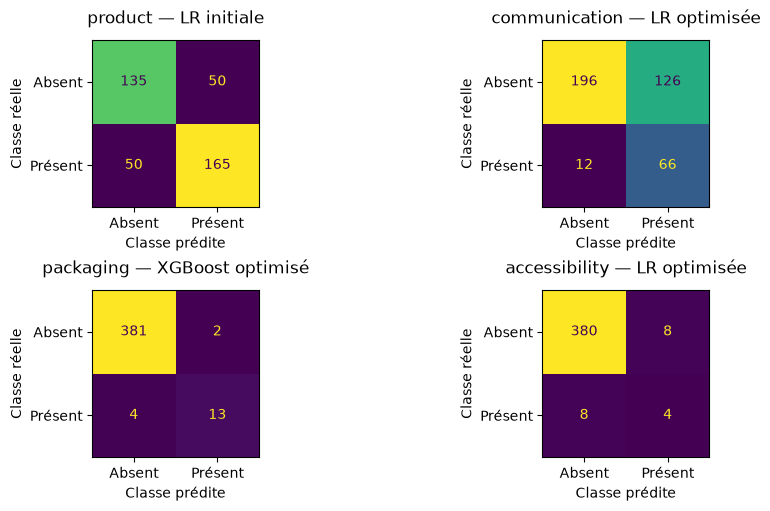

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5), constrained_layout=True)

for ax, (aspect, modele, predictions) in zip(axes.ravel(), matrices_a_afficher):
    
    i = liste_aspects.index(aspect)

    matrice = confusion_matrix(y_test[aspect], predictions[:, i])

    affichage = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=["Absent", "Présent"])

    affichage.plot(ax=ax, colorbar=False)

    ax.set_title(f"{aspect} — {modele}", pad=12)
    
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")

plt.show()

In [53]:
#import joblib
#from pathlib import Path

#dossier_modeles = Path("../models").resolve()
#dossier_modeles.mkdir(parents=True, exist_ok=True)

#fichier_aspects = dossier_modeles / "aspects_lr_pipeline.joblib"

#joblib.dump({"tfidf": tfidf, "modele": modele_lr_opt_aspects, "aspects": list(liste_aspects)}, fichier_aspects)

#print("Sauvegarde créée :", fichier_aspects)

Sauvegarde créée : D:\1 - IA DataScientest Machine learning engineer\Projet fil rouge-Trustpilot Aspect Intelligence\Part 2\Python\models\aspects_lr_pipeline.joblib
